In [1]:
# --- Core Packages ---
import os
import sys
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- SciPy / Stats ---
from scipy.optimize import curve_fit, fsolve
from scipy.stats import (
    mannwhitneyu, rankdata, spearmanr, skew,
    lognorm, gamma, norm, kstest, kruskal
)

import scipy.stats as stats
from scipy.interpolate import PchipInterpolator, interp1d

# --- Sympy (uncertainty) ---
import sympy as sp

# --- Statsmodels ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests

# --- Geospatial ---
import geopandas as gpd
import rasterio
import pycountry_convert as pc

# --- Matplotlib Add-ons ---
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter, FormatStrFormatter
import matplotlib.gridspec as gridspec

# --- Machine Learning ---
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LinearRegression

# --- Jupyter ---
from IPython.display import display

import re

# --- Pandas display options ---
pd.set_option('display.max_columns', None)

In [2]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 18,              # base font size
    "axes.titlesize": 24,          # subplot titles
    "axes.labelsize": 24,          # x/y labels
    "xtick.labelsize": 18,         # tick labels
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 24
})

In [3]:
#set path
folder = "/Users/uib/Documents/1.PhD-project/Paper1/Project_1/Python_scripts"
input_data = "/Input_data/"
output_data= "/Output_data/"

# Create df

## Load data

### Achtziger

In [4]:
# Load the Excel file
path_df = os.path.join(folder + input_data, 'Database_achtziger.xlsx')  # Replace folder and input_data with your variables

# Define the column names based on your provided list
column_names = [
    'Number', 'well name', 'site', 'location', 'country', 'latitude', 'longitude',
    'depth interval 1', 'depth interval 2', 'middle of intervals', 'length of intervals',
    'borehole radius', 'test volume', 'reported radius of influence', 'test duration',
    'test method', 'test procedure', 'temperature value', 'temperature literature',
    'reported as parameter', 'reported as unit', 'reported as figure', 'reported as value',
    'orientation of test section horizontal', 'orientation of test section oblique',
    'orientation of test section vertical', 'hydraulic conductivity mean',
    'hydraulic conductivity min', 'hydraulic conductivity max', 'permeability log mean',
    'permeability log min', 'permeability log max', 'used permeability log mean',
    'used permeability log min', 'used permeability log max', 'reported measurement limit m^2/s',
    'reported measurement limit m/s', 'reported measurement limit m^2', 'used measurement limit',
    'reported lithology', 'carbonate (marble)', 'quartzite', 'hornfelse-sandinite facies',
    'grenschit-blueschist and lower facies', 'amphibolite facies', 'franulite-edogite facies',
    'metamorphic plutonite', 'metamorphic volcanite', 'acid plutonic rocks',
    'intermediate plutonic rocks', 'basic plutonic rocks', 'lithology with others',
    'reference', 'comments', 'density at T/p', 'dynamic viscosity at T',
    'geological province', 'recent stress regime column A', 'recent stress regime column B',
    'recent stress regime column C', 'recent stress regime depth', 'recent stress regime regime',
    'reported stress regime at site regime', 'reported stress regime at site reference', 'pga'
]

# Read the Excel file
df_porosity = pd.read_excel(path_df, header=None, names=column_names, skiprows=4)


In [5]:
len_Achtiziger=len(df_porosity)
two_km_Achtziger=len(df_porosity[df_porosity['middle of intervals']<=2000])

Remove data with an interval exceeding 100 meters

In [6]:
# Convert the column to numeric, coercing errors to NaN
df_porosity['length of intervals'] = pd.to_numeric(df_porosity['length of intervals'], errors='coerce')

df_porosity = df_porosity[df_porosity['length of intervals'].le(100) | df_porosity['length of intervals'].isna()]



Discard permeabilities at or below the measurment limit

In [7]:
# Ensure 'permeability' and 'Used Measurement Limit[m^2]' columns are numeric
df_porosity['used permeability log mean'] = pd.to_numeric(df_porosity['used permeability log mean'], errors='coerce')
df_porosity['used measurement limit'] = pd.to_numeric(df_porosity['used measurement limit'], errors='coerce')

# Keep rows where permeability is >= the limit or the limit is NaN
df_porosity = df_porosity[
    (df_porosity['used permeability log mean'] >= df_porosity['used measurement limit']) |
    (df_porosity['used measurement limit'].isna())
]

Group methods

In [8]:
def classify_method(method):
    if pd.isna(method):
        return 'Unknown'
    
    method = method.lower()  # Make case-insensitive comparisons
    
    if method in ['double packer test', 'open hole pumping/slug tests', 'single packer test', 
                  'borehole lugeon/wd test', 'flow meter borehole logs', 'drill stem test', 
                  'hydrofrac']:
        return 'Hydraulic Borehole Measurements'
    elif method == 'pneumatic test':
        return 'Pneumatic Borehole Measurements'
    elif method in ['pressure tunnel tests']:
        return 'Pressure Tests in Tunnels'
    elif method == 'x-hole tracer test':
        return 'Tracer Data'
    elif method == 'discrete tunnel inflow measurement':
        return 'Analysis of Discrete Tunnel Inflow Measurements'
    elif method == '(induced) seismicity':
        return 'Indirect Determinations of Permeability'
    elif method == 'distributed inflows in ventilation tests':
        return 'Pressure Tests in Tunnels'
    elif method == 'measurement based aquifer scale model (isotopes, temperature, etc.)':
        return 'Indirect Determinations of Permeability'
    elif method in ['simulation test', 'simulation experiments', 'modeling tests']:  # Add your simulation test methods here
        return 'Simulation Tests'
    else:
        return 'Unknown'  # Return 'Unknown' for methods not in the predefined list

# Apply the classification function to the 'Test Methodnan' column
df_porosity['Group'] = df_porosity['test method'].apply(classify_method)

In [9]:
# Assuming df is your original DataFrame with the 'Group Classification' column
# First, count the number of observations in each group
group_counts = df_porosity['Group'].value_counts()

# Identify groups to keep based on the criteria
valid_groups = group_counts[(group_counts >= 100) & 
                             (~group_counts.index.isin(['Unknown', 'Tracer Data', 'Simulation Tests']))].index

# Create the df_porosity DataFrame by filtering the original DataFrame
df_porosity = df_porosity[df_porosity['Group'].isin(valid_groups)]


In [10]:
# Define the columns to keep and their new names
columns_to_keep = {
    'latitude': 'latitude',
    'longitude': 'longitude',
    'middle of intervals': 'depth',
    'used permeability log mean': 'log(k)',
    'Group': 'group',
    'length of intervals': 'length of intervals',
    'used measurement limit':'measurement limit',
    'country':'country',
    'reported lithology':'lithology',
    'test volume': 'test volume'
}


# Rename columns only (keep all others)
df_porosity = df_porosity.rename(columns=columns_to_keep)

# Remove the first two rows
df_porosity = df_porosity.iloc[2:]

# Drop rows where required columns are missing
df_porosity = df_porosity.dropna(subset=['depth', 'log(k)'])

# Reset index
df_porosity = df_porosity.reset_index(drop=True)



In [11]:
#create permeability
df_porosity["permeability"] = 10**df_porosity["log(k)"]
df_porosity["dataset"] = "Achtziger-Zupančič et al., 2017"

In [12]:
df_achtziger = df_porosity.rename(columns={'depth_middle': 'depth'})


In [13]:
#set search terms
search_terms_exclude_dict = {
    "granite": ["diorite", "gabbro", "tonalite", "syenite", "monzonite"],
    "granodiorite": ["tonalite", "diorite"],
    "gneiss": ["paragneiss", "ortho-gneiss"],
    "schist": ["micaschist", "mica-schist", "hornfels schist"],
    "phyllite": ["graphitic phyllite", "quartzitic phyllite"],
    "quartzite": [],
    "amphibolite": [],
    "migmatite": [],
    "pegmatite": [],
    "marble": [],
    "diorite": ["granite", "monzonite", "syenite"],
    "meta-diorite": ["diorite"],
    "meta-gabbro": ["gabbro"],
    "meta-rhyolite": [],
    "serpentinite": [],
    "kimberlite": [],
    "lamprophyre": [],
    "fels": [],
    "dolomite": [],
    "greenstone": ["greenschist"],
    "meta-basite": [],
    "meta-vulcanite": [],
    "meta-argillite": [],
    "tonalite": [],
    "syenite": [],
    "monzonite": [],
    "anorthosite": [],
    "rhyolite": [],
}



search_terms = list(search_terms_exclude_dict.keys())  # Extract search terms from the keys of search_terms_exclude_dict

def determine_category(lithology):
    if not isinstance(lithology, str):
        return None  
    
    lithology_lower = lithology.lower()  # Convert the lithology string to lowercase
    
    for term in search_terms:
        if term in lithology_lower:  # Check for match using lowercase versions
            excluded = any(exclude_term in lithology_lower for exclude_term in search_terms_exclude_dict[term])
            if not excluded:
                return term
    
    # If no category is found, return None
    return None

In [14]:
df_achtziger['lithology_category'] = df_achtziger['lithology'].apply(determine_category)

In [15]:
# Map old lithology categories to broader categories
lithology_to_category = {
    "tonalite": "granite",
    "monzonite": "granite",
    "syenite": "granite",
    "migmatite": "gneiss",
    "phyllite": "schist",
    "amphibolite": "schist",
    "meta-argillite": "volcanic/meta-volcanic",
    "meta-rhyolite": "volcanic/meta-volcanic",
    "meta-vulcanite": "volcanic/meta-volcanic",
    "marble": "carbonate",
    "dolomite": "carbonate",
    "anorthosite": "mafic intrusive",
    "greenstone": "other",
    "fels": "other",
    "kimberlite": "other"
    # Add more mappings here if you want
}

def map_or_keep(category):
    if pd.isna(category):
        return None
    category_lower = category.lower()
    # Try to map the category; if not found, keep original
    return lithology_to_category.get(category_lower, category_lower)

df_achtziger['combined_category'] = df_achtziger['lithology_category'].apply(map_or_keep)


In [16]:
df_achtziger['category'] = df_achtziger['lithology_category'].apply(map_or_keep)

In [17]:
df_achtziger.head()

,Number,well name,site,location,country,latitude,longitude,depth interval 1,depth interval 2,depth,length of intervals,borehole radius,test volume,reported radius of influence,test duration,test method,test procedure,temperature value,temperature literature,reported as parameter,reported as unit,reported as figure,reported as value,orientation of test section horizontal,orientation of test section oblique,orientation of test section vertical,hydraulic conductivity mean,hydraulic conductivity min,hydraulic conductivity max,permeability log mean,permeability log min,permeability log max,log(k),used permeability log min,used permeability log max,reported measurement limit m^2/s,reported measurement limit m/s,reported measurement limit m^2,measurement limit,lithology,carbonate (marble),quartzite,hornfelse-sandinite facies,grenschit-blueschist and lower facies,amphibolite facies,franulite-edogite facies,metamorphic plutonite,metamorphic volcanite,acid plutonic rocks,intermediate plutonic rocks,basic plutonic rocks,lithology with others,reference,comments,density at T/p,dynamic viscosity at T,geological province,recent stress regime column A,recent stress regime column B,recent stress regime column C,recent stress regime depth,recent stress regime regime,reported stress regime at site regime,reported stress regime at site reference,pga,group,permeability,dataset,lithology_category,combined_category,category
0,3,NaN,T-2 Power Cavern,Cabramurra (New South Wales),Australia,-35.88,148.37,21.3,21.3,21.3,NaN,0.0381,0.0,NaN,NaN,Double Packer Test,HI/RI,8.239,NaN,permeability,ft2,NaN,x,NaN,NaN,x,NaN,NaN,NaN,-12.134343,NaN,NaN,-12.134343,0.0,0.0,NaN,NaN,NaN,NaN,granite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,Snow (1979),NaN,999.918159,0.001366,OroPas,-36.43,148.6,65.0,9,TF,NaN,NaN,0.901574,Hydraulic Borehole Measurements,7.339340e-13,"Achtziger-Zupančič et al., 2017",granite,granite,granite
1,4,NaN,T-2 Power Cavern,Cabramurra (New South Wales),Australia,-35.88,148.37,27.4,27.4,27.4,NaN,0.0381,0.0,NaN,NaN,Double Packer Test,HI/RI,8.422,NaN,permeability,ft2,NaN,x,NaN,NaN,x,NaN,NaN,NaN,-12.764798,NaN,NaN,-12.764798,0.0,0.0,NaN,NaN,NaN,NaN,granite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,Snow (1979),NaN,999.930556,0.001359,OroPas,-36.43,148.6,65.0,9,TF,NaN,NaN,0.901574,Hydraulic Borehole Measurements,1.718706e-13,"Achtziger-Zupančič et al., 2017",granite,granite,granite
2,5,NaN,T-2 Power Cavern,Cabramurra (New South Wales),Australia,-35.88,148.37,33.5,33.5,33.5,NaN,0.0381,0.0,NaN,NaN,Double Packer Test,HI/RI,8.605,NaN,permeability,ft2,NaN,x,NaN,NaN,x,NaN,NaN,NaN,-12.521425,NaN,NaN,-12.521425,0.0,0.0,NaN,NaN,NaN,NaN,granite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,Snow (1979),NaN,999.942484,0.001352,OroPas,-36.43,148.6,65.0,9,TF,NaN,NaN,0.901574,Hydraulic Borehole Measurements,3.010058e-13,"Achtziger-Zupančič et al., 2017",granite,granite,granite
3,6,NaN,T-2 Power Cavern,Cabramurra (New South Wales),Australia,-35.88,148.37,41.5,41.5,41.5,NaN,0.0381,0.0,NaN,NaN,Double Packer Test,HI/RI,8.845,NaN,permeability,ft2,NaN,x,NaN,NaN,x,NaN,NaN,NaN,-10.088476,NaN,NaN,-10.088476,0.0,0.0,NaN,NaN,NaN,NaN,granite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,Snow (1979),NaN,999.957420,0.001342,OroPas,-36.43,148.6,65.0,9,TF,NaN,NaN,0.901574,Hydraulic Borehole Measurements,8.156887e-11,"Achtziger-Zupančič et al., 2017",granite,granite,granite
4,7,NaN,T-2 Power Cavern,Cabramurra (New South Wales),Australia,-35.88,148.37,54.9,54.9,54.9,NaN,0.0381,0.0,NaN,NaN,Double Packer Test,HI/RI,9.247,NaN,permeability,ft2,NaN,x,NaN,NaN,x,NaN,NaN,NaN,-12.258184,NaN,NaN,-12.258184,0.0,0.0,NaN,NaN,NaN,NaN,granite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,Snow (1979),NaN,999.980656,0.001327,OroPas,-36.43,148.6,65.0,9,TF,NaN,NaN,0.901574,Hydraulic Borehole Measurements,5.518441e-13,"Achtziger-Zupančič et al., 2017",granite,granite,granite


### Kuang et al. 

In [18]:
#load
path_df = os.path.join(folder+input_data, 'Kuang_et_al..xlsx')
df_Kuang= pd.read_excel(path_df)

In [19]:
df_Kuang.head()

,Country,Locality,z (km),logk (m2),Error logk,Error z,Reference,Description,Source
0,Unkown,Thermal models,0.50,-12.9,0.0,0.00,Manning and Ingebritsen [1999],general continental crust,"Kuang, X., & Jiao, J. J. (2014). An integrated..."
1,Unkown,Thermal models,0.85,-13.6,-0.4,0.35,Manning and Ingebritsen [1999],general continental crust,"Kuang, X., & Jiao, J. J. (2014). An integrated..."
2,Unkown,Thermal models,1.00,-14.2,-0.1,1.00,Manning and Ingebritsen [1999],general continental crust,"Kuang, X., & Jiao, J. J. (2014). An integrated..."
3,Unkown,Thermal models,1.50,-13.9,-0.4,1.50,Manning and Ingebritsen [1999],general continental crust,"Kuang, X., & Jiao, J. J. (2014). An integrated..."
4,Unkown,Thermal models,2.50,-15.0,NaN,2.50,Manning and Ingebritsen [1999],general continental crust,"Kuang, X., & Jiao, J. J. (2014). An integrated..."


In [20]:
#remove values for oceanic crust and disturbed continental crust
values_to_remove = ['oceanic crust', 'disturbed continental crust']

# Remove rows where the Description is in values_to_remove
df_Kuang= df_Kuang[~df_Kuang['Description'].isin(values_to_remove)]


In [21]:
len_Kuang=len(df_Kuang)
two_km_Kuang=len(df_Kuang[df_Kuang['z (km)']<=2000])

In [22]:
deep_point = 2 #km

In [23]:
# Define values to remove
values_to_remove1 = [ 'Louis [1974]','Morrow and Byerlee [1988]', 'Neuzil [1986]']
df_Kuang = df_Kuang[~(df_Kuang['Reference'].isin(values_to_remove1))]

#values to remove if they are in the upper two kilomters, because of modelling
values_to_remove2 = [ 'Bredehoeft et al. [1992]','Manning and Ingebritsen [1999]', 'Saar and Manga [2004]','Bredehoeft et al. [1994]']
df_Kuang = df_Kuang[~((df_Kuang['Reference'].isin(values_to_remove2)) & (df_Kuang['z (km)'] < deep_point))]

# Update 'Country' for a specific reference
df_Kuang.loc[df_Kuang['Reference'] == 'Manning and Ingebritsen [1999]', 'Country'] = 'Unknown'
# Update 'Country' for a specific reference
df_Kuang.loc[df_Kuang['Reference'] == 'Bredehoeft et al. [1994]', 'Country'] = 'USA'


In [24]:
#create permeability column
df_Kuang['permeability'] = 10 ** df_Kuang['logk (m2)'].astype(float)

#rename columns
df_Kuang.rename(columns={
    'z (km)': 'depth',
    'Source': 'dataset',
    'Reference': 'source',
    'Description': 'remarks',
    'Locality': 'location',
    'Country':'country'
}, inplace=True)

df_Kuang['depth']=df_Kuang['depth']*1000



In [25]:
df_Kuang = df_Kuang[['location', 'depth', 'dataset', 'permeability', 'country','source']]

## Combine

In [26]:
# Concatenate the two DataFrames
df = pd.concat([df_achtziger, df_Kuang], axis=0, ignore_index=True)
df = df.sort_values('depth', ascending=True).reset_index(drop=True)

In [27]:
df.tail()

,Number,well name,site,location,country,latitude,longitude,depth interval 1,depth interval 2,depth,length of intervals,borehole radius,test volume,reported radius of influence,test duration,test method,test procedure,temperature value,temperature literature,reported as parameter,reported as unit,reported as figure,reported as value,orientation of test section horizontal,orientation of test section oblique,orientation of test section vertical,hydraulic conductivity mean,hydraulic conductivity min,hydraulic conductivity max,permeability log mean,permeability log min,permeability log max,log(k),used permeability log min,used permeability log max,reported measurement limit m^2/s,reported measurement limit m/s,reported measurement limit m^2,measurement limit,lithology,carbonate (marble),quartzite,hornfelse-sandinite facies,grenschit-blueschist and lower facies,amphibolite facies,franulite-edogite facies,metamorphic plutonite,metamorphic volcanite,acid plutonic rocks,intermediate plutonic rocks,basic plutonic rocks,lithology with others,reference,comments,density at T/p,dynamic viscosity at T,geological province,recent stress regime column A,recent stress regime column B,recent stress regime column C,recent stress regime depth,recent stress regime regime,reported stress regime at site regime,reported stress regime at site reference,pga,group,permeability,dataset,lithology_category,combined_category,category,source
27968,NaN,NaN,NaN,Experimental,Russia,NaN,NaN,NaN,NaN,35650.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.897788e-22,"Kuang, X., & Jiao, J. J. (2014). An integrated...",NaN,NaN,NaN,Shmonov et al. [2003]
27969,NaN,NaN,NaN,Experimental,Russia,NaN,NaN,NaN,NaN,35650.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.071519e-22,"Kuang, X., & Jiao, J. J. (2014). An integrated...",NaN,NaN,NaN,Shmonov et al. [2003]
27970,NaN,NaN,NaN,Experimental,Russia,NaN,NaN,NaN,NaN,35650.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.884032e-23,"Kuang, X., & Jiao, J. J. (2014). An integrated...",NaN,NaN,NaN,Shmonov et al. [2003]
27971,NaN,NaN,NaN,Experimental,Russia,NaN,NaN,NaN,NaN,35650.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.513561e-20,"Kuang, X., & Jiao, J. J. (2014). An integrated...",NaN,NaN,NaN,Shmonov et al. [2003]
27972,NaN,NaN,NaN,Experimental,Russia,NaN,NaN,NaN,NaN,35650.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.760830e-19,"Kuang, X., & Jiao, J. J. (2014). An integrated...",NaN,NaN,NaN,Shmonov et al. [2003]


# Porosity


### Create functions

porosity = K * 12 * f / b^2 * 100 for procent
With:
K = permeability
f = fracture surface characteristic factor
b = aperture


In [28]:
#create a function to estimate porosity
def porosity_value(permeability,f, aperture):
    porosity = permeability*12*f/(aperture**2)
    return porosity

In [29]:
def porosity_value_snow(permeability, aperture):
    porosity=5.45*(permeability/(0.6**2))**(1/3)
    return porosity

In [30]:
def aperture_value_Bisdom(initial_aperture_m, init_norm_stiffness_Pa_per_m):
    # Convert units
    aperture_mm = initial_aperture_m * 1000
    stiffness_MPa_per_mm = init_norm_stiffness_Pa_per_m / 1000  # Pa/m → MPa/mm

    # Barton-Bandis parameters
    JRC = 15
    JCS = 200  # MPa

    # Compute vm and delta_l using mm-based aperture
    vm = -0.1032 - 0.0074 * JRC + 1.135 * ((JCS / aperture_mm) ** -0.251)
    delta_l = -7.15 + 1.75 * JRC + 0.02 * (JCS / aperture_mm)

    # Closure calculation
    delta_e_mm = 1 / ((1 / vm) + (stiffness_MPa_per_mm / delta_l))
    aperture_mm_new = aperture_mm - delta_e_mm

    # Convert back to meters
    return aperture_mm_new / 1000

In [31]:
#create a function to calculate aperture based on depth

#equation aperture with depth
def aperture_with_depth(initial_aperture,resid_aperture,eff_norm_stress,init_norm_stiffness):
    aperture = initial_aperture - (eff_norm_stress/(init_norm_stiffness+(eff_norm_stress/(initial_aperture-resid_aperture))))
    return aperture

def aperture_value(depth, initial_aperture, reduction_value, init_norm_stiffness, bulk_density, angle):
    
    #residential aperture   
    resid_aperture = initial_aperture*(1-reduction_value)
    
    #effective normal stress
    acc_grav=9.81
    eff_norm_stress = effective_normal_stress(depth,bulk_density,angle)

    #apply equation aperture with depth
    aperture=aperture_with_depth(initial_aperture,resid_aperture,eff_norm_stress,init_norm_stiffness)

    return aperture
    

In [32]:
def effective_normal_stress(depth,bulk_density,angle):
    total_normal_stress=total_normal_stress_value(depth,bulk_density=bulk_density,angle=angle)
    fluid_pressure=fluid_pressure_value(depth)
    
    eff_norm_stress = total_normal_stress-fluid_pressure
    return eff_norm_stress

def total_normal_stress_value(depth, bulk_density, angle):
    acc_grav = 9.81
    angle_rad = np.radians(angle)  # Convert angle to radians
    total_normal_stress = bulk_density * acc_grav * depth * (np.cos(angle_rad))
    return total_normal_stress
    
def fluid_pressure_value(depth):
    acc_grav=9.81
    density_water=calculate_fluid_density(depth)
    fluid_pressure = density_water*acc_grav*depth
    return fluid_pressure
    

In [33]:
# Constants
R = 83.14467  # cm³·bar/(mol·K)
M_H2O = 18.015  # g/mol (Molar mass of water)
Tc = 647.25  # K (Critical temperature of water)
Vc = 55.9480373  # cm³/mol (Critical volume of water)

# EOS Parameters
params = {
    "a1": 3.49824207e-01, "a2": -2.91046273e+00, "a3": 2.00914688e+00,
    "a4": 1.12819964e-01, "a5": 7.48997714e-01, "a6": -8.73207040e-01,
    "a7": 1.70609505e-02, "a8": -1.46355822e-02, "a9": 5.79768283e-02,
    "a10": -8.41246372e-04, "a11": 4.95186474e-03, "a12": -9.16248538e-03,
    "a13": -1.00358152e-01, "a14": -1.82674744e-03, "gamma": 1.05999998e-02
}

# EOS function to solve for molar volume V
def eos_function(V, T, P):
    Vr = V / Vc  # Reduced volume
    Tr = T / Tc  # Reduced temperature

    # Compute EOS terms
    B = params["a1"] + params["a2"] / Tr**2 + params["a3"] / Tr**3
    C = params["a4"] + params["a5"] / Tr**2 + params["a6"] / Tr**3
    D = params["a7"] + params["a8"] / Tr**2 + params["a9"] / Tr**3
    E = params["a10"] + params["a11"] / Tr**2 + params["a12"] / Tr**3
    F = params["a13"] / Tr
    G = params["a14"] * Tr

    Z = (1 + B/Vr + C/Vr**2 + D/Vr**4 + E/Vr**5 +
         ((F/Vr**2 + G/Vr**4) * np.exp(-params["gamma"] / Vr**2)))
    
    return (Z * R * T / P) - V  # Solve for V

def calculate_Z(V, T, P):
    Vr = V / Vc  # Reduced volume
    Tr = T / Tc  # Reduced temperature

    # Compute EOS terms
    B = params["a1"] + params["a2"] / Tr**2 + params["a3"] / Tr**3
    C = params["a4"] + params["a5"] / Tr**2 + params["a6"] / Tr**3
    D = params["a7"] + params["a8"] / Tr**2 + params["a9"] / Tr**3
    E = params["a10"] + params["a11"] / Tr**2 + params["a12"] / Tr**3
    F = params["a13"] / Tr
    G = params["a14"] * Tr

    Z = (1 + B/Vr + C/Vr**2 + D/Vr**4 + E/Vr**5 +
         ((F/Vr**2 + G/Vr**4) * np.exp(-params["gamma"] / Vr**2)))
    
    return Z

def calculate_fluid_density(z):
    P = 1000 * 9.81 * z / (10**5)  # Pressure in bar
    T = (z / 1000) * 25 + 273.15   # Temperature in K

    # Initial guess for molar volume (Vc is a good starting point)
    V_guess = 18

    # Solve for V using the EOS function
    V_solution = fsolve(eos_function, V_guess, args=(T, P))[0]

    # Calculate Z
    Z = calculate_Z(V_solution, T, P)

    # Calculate density using ρ = M * P / (Z * R * T)
    rho = (M_H2O * P) / (Z * R * T)  # Density in g/cm³

    return rho * 1000  # Convert to kg/m³

## Parameters

In [34]:
initial_aperture=171*(10**-6) #[m] 
bulk_density=2660 #[kg/m3]
angle=45 #[degrees]
reduction_value=0.86 #[-]
init_norm_stiffness=5*10**9 #[N/m]
f_value = 1.31 #[-]

## apply functions

In [35]:
#calculate water density
df['fluid_density'] = df.apply(lambda row: calculate_fluid_density(row['depth']), axis=1)
df['fluid_pressure'] = df.apply(lambda row: fluid_pressure_value(row['depth']), axis=1)

#calculte total normal stress
df['total_normal_stress'] = df.apply(lambda row: total_normal_stress_value(row['depth'],bulk_density,angle), axis=1)

#calculate effective normal stress
df['eff_normal_stress'] = df.apply(lambda row: effective_normal_stress(row['depth'],bulk_density,angle), axis=1)

#create columns with aperture values
df['aperture'] = df.apply(lambda row: aperture_value(row['depth'], initial_aperture,reduction_value,init_norm_stiffness,bulk_density,angle), axis=1)

In [36]:
# #calculate porosity
df['porosity'] = df.apply(lambda row: porosity_value(row['permeability'], f_value, row['aperture']), axis=1)


In [37]:
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
df['porosity'] = pd.to_numeric(df['porosity'], errors='coerce')
df['log(porosity)']=np.log10(df['porosity'])
df['log_depth'] = np.log10(df['depth'])  # Use natural logarithm

# Drop rows with NaN in 'depth' or 'log(porosity)'
df = df.dropna(subset=['depth', 'log(porosity)'])


## Remove unrealistic values

In [38]:
#count how often unrealistic porosity
condition = (df['porosity'] > 1) | (df['porosity'] < 0)
filtered_df = df[condition]

print(len(filtered_df))
df = df[~condition]

7


# Paper results

In [39]:
#create two depth scenarios
df_begin=df[df['depth']<=deep_point*1000].copy()
df_all=df.copy()

In [40]:
#Pangaea ready table
df['fracture_density']=df['porosity']/df['aperture']

df_clean = df.copy()
df_clean = df_clean.rename(columns={
    "site": "Site",
    "latitude": "Latitude (deg)",
    "longitude": "Longitude (deg)",
    "country": "Country",
    "depth": "Depth (m)",
    "permeability": "Permeability (m^2)",
    "test_method": "Test method",
    "porosity": "Porosity (%)",
    "fracture_density": "Fracture density",
    "test method": "Test method",
    "dataset": "Dataset",
    "source": "Source1",
    "reference": "Source2"
})

df_clean["Sample ID"] = ["S" + str(i+1) for i in range(len(df_clean))]



df_clean["Porosity (%)"]=df_clean["Porosity (%)"]*100

df_clean['Source'] = df_clean['Source1'].combine_first(df_clean['Source2'])

df_clean = df_clean[
    [
        "Sample ID",
        "Site",
        "Latitude (deg)",
        "Longitude (deg)",
        "Country",
        "Depth (m)",
        "Permeability (m^2)",
        "Test method",
        "Porosity (%)",
        "Fracture density",
        #"Source",
        "Dataset"
    ]
]

In [41]:

numeric_cols = ["Depth (m)", "Permeability (m^2)", "Porosity (%)"]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean = df_clean.replace(["", " ", "NA", "NaN"], pd.NA)

In [42]:
df_clean.to_csv(f"{folder}{output_data}/pangea_dataset.csv", index=False)

In [43]:
df_clean.head()

,Sample ID,Site,Latitude (deg),Longitude (deg),Country,Depth (m),Permeability (m^2),Test method,Porosity (%),Fracture density,Dataset
0,S1,Olkiluoto,61.24,21.46,Finland,0.50000,3.119580e-15,Single Packer Test,0.000169,0.009958,"Achtziger-Zupančič et al., 2017"
2,S2,Virginia Ranch Damsite,39.34,-121.33,USA,1.20000,4.580120e-13,Double Packer Test,0.025227,1.493218,"Achtziger-Zupančič et al., 2017"
3,S3,Blue Mesa Damsite,38.45,-107.33,USA,1.42875,1.672255e-11,Double Packer Test,0.925275,54.894481,"Achtziger-Zupančič et al., 2017"
4,S4,Alto Garcia Dam,-26.87,-48.79,Brasil,1.50000,4.557034e-14,Borehole Lugeon/WD Test,0.002525,0.149911,"Achtziger-Zupančič et al., 2017"
5,S5,Trinity Damsite,40.80,-122.76,USA,1.50000,1.096256e-11,Double Packer Test,0.607432,36.063217,"Achtziger-Zupančič et al., 2017"


In [44]:
# print(df_clean['Source'].unique())

## Functions

#### Line fits

In [45]:
#calculate linear fit

def linear_func(log_depth, a, b):
    return a * log_depth + b

def linear_fit(df, printing='on'):
        
    # Prepare data for fitting directly using the original data
    x_data = df['log_depth']
    y_data = df['log(porosity)']
    
    # Remove NaN values
    valid = ~np.isnan(y_data)
    x_data = x_data[valid]
    y_data = y_data[valid]
    
    # Fit the linear curve using all data points
    params, _ = curve_fit(linear_func, x_data, y_data, p0=(1, 0))
    
    # Calculate R² using all data
    ss_res = np.sum((y_data - linear_func(x_data, *params)) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    if printing=='on':
        print(f"Linear Fit Formula: log(porosity) = {params[0]:.4f} * log(depth) + {params[1]:.4f}")
        print(f"Porosity = 10**({params[1]:.4f}) * depth**({params[0]:.4f})")
        print(f"R² = {r_squared:.2f}")
    
    return params, r_squared

def porosity_formula(df):
    params, r_squared = linear_fit(df)
    m = params[0]  # slope
    b = params[1]  # intercept
    
    print(f"porosity = 10**({b:.2f}) * depth**({m:.2f})")

    return m,b


#### Origin data

In [46]:
warnings.filterwarnings("ignore")

def figure_1():
    
    # === Depth histogram setup ===
    custom_bins = [0, 100, 250, 500, 1000, 2000, 36000]
    bin_labels = [f"{custom_bins[i]}-{custom_bins[i+1]}" for i in range(len(custom_bins)-1)]
    counts, _ = np.histogram(df['depth'], bins=custom_bins)

    # === Load and prepare basemap ===
    shapefile_path = "/Users/uib/Downloads/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
    world = gpd.read_file(shapefile_path)
    
    # === Spatial clustering for datapoints ===
    geo_df = df[['latitude', 'longitude']].dropna()
    coords = np.radians(geo_df[['latitude', 'longitude']].values)
    
    kms_per_radian = 6371.0088
    epsilon = 100 / kms_per_radian  # 100 km in radians
    
    db = DBSCAN(eps=epsilon, min_samples=1, algorithm='ball_tree', metric='haversine').fit(coords)
    labels = db.labels_
    
    geo_df['cluster'] = labels
    cluster_sizes = geo_df.groupby('cluster').size()
    centroids = geo_df.groupby('cluster')[['latitude', 'longitude']].mean()
    
    # === Colormap and normalization ===
    cmap = mcolors.LinearSegmentedColormap.from_list("white_to_darkbrown", ["white", "#4F4789"])

    norm = LogNorm(vmin=cluster_sizes.min(), vmax=cluster_sizes.max())
    
    # === Create combined figure ===
    fig = plt.figure(figsize=(24, 12))
    
    # === Histogram subplot (left) ===
    ax1 = plt.subplot2grid((6, 3), (2, 0), rowspan=6)
    ax1.bar(bin_labels, counts, color='#D3D3D3', edgecolor='black')
    ax1.set_xlabel('Depth Range [m]', fontsize=18)
    ax1.set_ylabel('Frequency', fontsize=18)
    ax1.set_xticks(range(len(bin_labels)))
    ax1.set_xticklabels(bin_labels, rotation=45, fontsize=16)
    ax1.tick_params(axis='y', labelsize=16)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.text(-0.1, 1.0, '(a)', transform=ax1.transAxes, fontsize=18, verticalalignment='top', horizontalalignment='left', fontweight='bold')
    
    # === Clustered dots map subplot (right) ===
    ax2 = plt.subplot2grid((6, 3), (2, 1), rowspan=5, colspan=2)  # Shift map down
    world.boundary.plot(ax=ax2, linewidth=0.5, color='black')
    world.plot(
    ax=ax2,
    facecolor="#D3D3D3",
    edgecolor="black",
    linewidth=0.4,
    zorder=1
)

    
    # === Scatter plot for cluster centroids ===
    sizes = np.log1p(cluster_sizes.values) * 40  # size scaling
    colors = cmap(norm(cluster_sizes.values))    # color scaling
    
    sc = ax2.scatter(centroids['longitude'], centroids['latitude'],
                     s=sizes,
                     alpha=0.8,
                     c=colors,
                     edgecolors='black',
                     linewidths=0.8,
                     zorder=3)
    
    # === Combined size and color legend ===
    size_refs = [10, 100, 1000, 5000, 10000]
    size_legend = [np.log1p(s) * 40 for s in size_refs]
    
    for size, s in zip(size_refs, size_legend):
        ax2.scatter([], [], 
                    s=s, 
                    color=cmap(norm(size)), 
                    edgecolors='black', 
                    label=f"{size:,}")
    
    legend = ax2.legend(
        title='Cluster Size',
        loc='upper center',
        bbox_to_anchor=(0.5, 0.03),  # Move to center and below the map
        fontsize=16,
        title_fontsize=18,
        labelspacing=1.2,
        handletextpad=1.5,
        borderpad=1.2,
        ncol=6,
        frameon=True
    )

    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('gray')
    legend.get_frame().set_edgecolor('none')
    
    # === Annotate panel ===
    ax2.text(0, 0.95, '(b)', transform=ax2.transAxes, fontsize=18, verticalalignment='top', horizontalalignment='left', fontweight='bold')
    ax2.axis('off')
    
    # === Adjust layout ===
    plt.subplots_adjust(wspace=0.05)
    plt.tight_layout()
    
    # === Save and show ===
    plt.savefig(f"{folder}{output_data}/figS01.png", dpi=900, bbox_inches='tight',transparent=True)
    plt.show()


In [47]:
def country_distribution(df):

    def get_continent(country_name):
        try:
            country_code = pc.country_name_to_country_alpha2(country_name)
            continent_code = pc.country_alpha2_to_continent_code(country_code)
            return {
                "AF": "Africa",
                "AS": "Asia",
                "EU": "Europe",
                "NA": "North America",
                "SA": "South America",
                "OC": "Oceania",
                "AN": "Antarctica"
            }.get(continent_code)
        except:
            return None

    # ✅ Remove only unknown / unkown / unknown-like entries
    df = df[~df['country'].str.lower().isin(['unknown', 'unkown'])].copy()

    # Count occurrences per country
    countries_df = df['country'].value_counts().reset_index()
    countries_df.columns = ['country', 'value']

    # ✅ Print how many different countries there are
    num_countries = countries_df['country'].nunique()
    print(f"Number of different countries in data (excluding unknowns): {num_countries}")

    # ✅ Print the list of countries
    countries_list = countries_df['country'].tolist()
    print("List of countries:")
    print(", ".join(countries_list))
    print()

    # Map each country to a continent
    countries_df['continent'] = countries_df['country'].apply(get_continent)

    # Group by continent and calculate totals and percentages
    df_continents = (
        countries_df
        .groupby('continent')['value']
        .sum()
        .reset_index()
        .rename(columns={'value': 'total_values'})
    )

    total_sum = df_continents['total_values'].sum()
    df_continents['percent'] = (df_continents['total_values'] / total_sum * 100).round(2)

    print(df_continents)


#### porosity vs permeability

#### IQR porosity

In [48]:
def calculate_IQR_original(df):

    median_porosity = df['porosity'].median()
    #rint(f"Median Porosity: {median_porosity:.2e}")
    
    # Assuming your DataFrame is named df
    Q1 = df['porosity'].quantile(0.25)
    Q3 = df['porosity'].quantile(0.75)
    IQR = Q3 - Q1

    print(f"Q1:{Q1:.2e}, Q3:{Q3:.2e}")

    return IQR

In [49]:
#procent van median
def procent_iqr(iqr,median):
    procent=iqr/median*100
    return procent

#procent difference
def procent_diff(new, old):
    diff = (new-old)/old*100
    print(f"Diff = {diff:.2f}%")

#### Calculate uncertainity

##### Check distributions

In [50]:


def uncertainty_parameter(parameter_list):
    # Convert to numpy array and clean data
    parameter_list = np.array(parameter_list, dtype=float)
    parameter_list = parameter_list[~np.isnan(parameter_list)]
    parameter_list = parameter_list[parameter_list > 0]

    result_dict = {
        "is_normal": None,
        "best_fit": None,
        "p_value": None,
        "params": None
    }

    if len(parameter_list) < 6:
        print("Warning: Very few data points. Normality tests may be unreliable.")
        result_dict["is_normal"] = True  # Assume normal for simplicity
        return result_dict

    # Anderson-Darling normality test
    ad_result = stats.anderson(parameter_list)
    # At 5% significance level, check if statistic < critical value
    is_normal = ad_result.statistic < ad_result.critical_values[2]
    result_dict["is_normal"] = is_normal

    if is_normal:
        print("Data appears to be normally distributed (Anderson-Darling test).")
        return result_dict

    print("Data does NOT follow a normal distribution.")

    # Try fitting alternative distributions
    distributions = {
        "Exponential": stats.expon,
        "Gamma": stats.gamma,
        "Log-Normal": stats.lognorm,
        "Weibull": stats.weibull_min,
        "Pareto": stats.pareto
    }

    best_fit = None
    best_p_value = 0
    best_params = None

    for name, dist in distributions.items():
        try:
            params = dist.fit(parameter_list)
            cdf_func = lambda x: dist.cdf(x, *params)
            _, p = stats.kstest(parameter_list, cdf_func)

            if p > best_p_value:
                best_p_value = p
                best_fit = name
                best_params = params

        except Exception as e:
            print(f"Skipping {name} distribution due to error: {e}")

    if best_fit and best_p_value >= 0.05:
        print(f"Best fit: {best_fit} distribution (p = {best_p_value:.3f})")
        result_dict.update({
            "best_fit": best_fit,
            "p_value": best_p_value,
            "params": best_params
        })
    else:
        print("No suitable parametric distribution found.")

    return result_dict



In [51]:
print('\033[1minitial aperture values\033[0m')
b0_values = [360,176,166,205,64,145.1,120,76.3,43.1,262,627,101,650,283,313,462,417,216,84,161]
multiplied_b0_values = np.array(b0_values) * (10**-6)
uncertainty_parameter(multiplied_b0_values)
print('\n')

print('\033[1mnormal stiffness\033[0m')
uncertainty_parameter([10**10,3.2*10**9,3.2*10**10,10**11,3.2*10**10,10**11,10**10,2*10**9, 1.6*10**9, 5*10**9, 3.2*10**9,10**10,1.6*10**9, 2*10**9, 3.2*10**9,10**10,4*10**9])
print('\n')

print('\033[1mf values\033[0m')
uncertainty_parameter([1.21,1.15,1.04,1.49,1.29,1.32,1.45,1.65,1.1,1.36,1.36,1.05]  )
print('\n')

print('\033[1mresident aperture\033[0m')
uncertainty_parameter([-90, -88, -89, -86, -84, -83] )


initial aperture values
Data does NOT follow a normal distribution.
Best fit: Log-Normal distribution (p = 1.000)


normal stiffness
Data does NOT follow a normal distribution.
Best fit: Gamma distribution (p = 0.767)


f values
Data appears to be normally distributed (Anderson-Darling test).


resident aperture


{'is_normal': True, 'best_fit': None, 'p_value': None, 'params': None}

In [52]:
for depth in range(0, 36000, 100):
    row = df.loc[(df['depth'] - depth).abs().idxmin()]

    # Filter rows within the given window range
    mask = (df['depth'] > depth - 0.5 * 100) & (df['depth'] < depth + 0.5 * 100)
    if len(df[mask]) <= 3:
        mask = (df['depth'] > depth - 0.5 * 1000) & (df['depth'] < depth + 0.5 * 1000)

    # Get permeability list from filtered rows
    permeability_list = df.loc[mask, 'permeability'].tolist()
    
    if len(permeability_list) > 4:
        print(f"\033[1mdepth: {depth} meters\033[0m")
        uncertainty_parameter(permeability_list)



depth: 0 meters
Data does NOT follow a normal distribution.
No suitable parametric distribution found.
depth: 100 meters
Data does NOT follow a normal distribution.
No suitable parametric distribution found.
depth: 200 meters
Data does NOT follow a normal distribution.
No suitable parametric distribution found.
depth: 300 meters
Data does NOT follow a normal distribution.
No suitable parametric distribution found.
depth: 400 meters
Data does NOT follow a normal distribution.
No suitable parametric distribution found.
depth: 500 meters
Data does NOT follow a normal distribution.
No suitable parametric distribution found.
depth: 600 meters
Data does NOT follow a normal distribution.
No suitable parametric distribution found.
depth: 700 meters
Data does NOT follow a normal distribution.
No suitable parametric distribution found.
depth: 800 meters
Data does NOT follow a normal distribution.
No suitable parametric distribution found.
depth: 900 meters
Data does NOT follow a normal distribut

##### Set up uncertainity

In [53]:
def uncertainty_parameter_normal(parameter_list):
    # Convert to NumPy array and clean data
    parameter_list = np.array(parameter_list, dtype=float)
    parameter_list = parameter_list[~np.isnan(parameter_list)]  # Remove NaNs
    parameter_list = parameter_list[parameter_list > 0]  # Remove non-positive values

    if len(parameter_list) < 3:  # Ensure enough data for statistics
        return np.nan, np.nan

    # Compute mean and standard deviation
    mean_parameter = np.mean(parameter_list)
    uncertainty_parameter = np.std(parameter_list, ddof=1)  # Sample std dev

    return mean_parameter, uncertainty_parameter

In [54]:
def bootstrap_data(data, N_SAMPLES=10000):
    n_samples = len(data)
    bootstrap_samples = np.random.choice(data, size=N_SAMPLES, replace=True)

    return bootstrap_samples

In [55]:
N_SAMPLES = 10000  #1000
window = 1000  

np.random.seed(7)

# Given constants
acc_grav = 9.81

In [56]:
mean_f,uncertainty_f = uncertainty_parameter_normal([1.21,1.15,1.04,1.49,1.29,1.32,1.45,1.65,1.1,1.36,1.36,1.05]  )
f_samples = np.random.normal(mean_f, uncertainty_f, N_SAMPLES)  # f ~ N(mean, std) 

"""------------------------------------"""
shape, loc, scale = lognorm.fit(multiplied_b0_values)
initial_aperture_samples = lognorm.rvs(shape, loc=loc, scale=scale, size=N_SAMPLES)
"""------------------------------------"""
values = np.array([
    1e10, 3.2e9, 3.2e10, 1e11, 3.2e10, 1e11, 1e10, 2e9, 1.6e9, 5e9,
    3.2e9, 1e10, 1.6e9, 2e9, 3.2e9, 1e10, 4e9
])
shape, loc, scale = gamma.fit(values, floc=0)
init_norm_stiff_samples = gamma.rvs(shape, loc=loc, scale=scale, size=N_SAMPLES)

"""------------------------------------"""
angle_samples = np.random.uniform(0, 90, N_SAMPLES)

"""------------------------------------"""
br_samples = bootstrap_data([0.9, 0.88, 0.89, 0.86, 0.84, 0.83], N_SAMPLES)

"""------------------------------------"""
permeability_incluided='on'

##### Uncertainity and corresponding plot

In [57]:
def calculate_uncertainty(df):
    # === Preparation ===
    df = df.sort_values(by='depth').reset_index(drop=True)
    num_rows = len(df)

    # Initialize storage
    results = {
        'depth': [],
        'median': [],
        'lower_bound': [],
        'upper_bound': [],
        'IQR': [],
        'porosity_original': [],
    }
    all_samples = []

    # === Iterate through each row ===
    for _, row in df.iterrows():
        depth = row['depth']
        porosity = row['porosity']
        k = row['permeability']
        rho_f = row['fluid_density']

        # Derived parameters
        k_samples = k * np.exp(np.random.uniform(np.log10(0.55), np.log10(3.3), size=N_SAMPLES))
        fluid_pressure = rho_f * acc_grav * depth

        total_normal_stress = bulk_density * acc_grav * depth * np.cos(np.radians(angle_samples))
        effective_stress = total_normal_stress - fluid_pressure

        # Aperture and Y calculation
        aperture = initial_aperture_samples - (
            effective_stress / (
                init_norm_stiff_samples + (effective_stress / (initial_aperture_samples * br_samples))
            )
        )
        Y_samples = (k_samples * 12 * f_samples) / (aperture ** 2)

        # Uncertainty stats
        median = np.median(Y_samples)
        lower = np.percentile(Y_samples, 25)
        upper = np.percentile(Y_samples, 75)
        iqr = upper - lower

        # Append results
        results['depth'].append(depth)
        results['median'].append(median)
        results['lower_bound'].append(lower)
        results['upper_bound'].append(upper)
        results['IQR'].append(iqr)
        results['porosity_original'].append(porosity)
        all_samples.append(Y_samples)

    # === Create result DataFrames ===
    results_df = pd.DataFrame(results)

    all_samples_df = pd.DataFrame(all_samples)
    all_samples_df.insert(0, 'depth', results['depth'])

    all_samples_array = all_samples_df.drop(columns='depth').values.flatten()
    all_samples_array = all_samples_array[~np.isnan(all_samples_array)]

    # === Summary statistics ===
    median_median = results_df['median'].median()
    median_lower = results_df['lower_bound'].median()
    median_upper = results_df['upper_bound'].median()

    # === Merge back to original df ===
    df_merged = df.merge(
        results_df[['depth', 'porosity_original', 'median', 'lower_bound', 'upper_bound', 'IQR']],
        left_index=True, right_index=True,
        how='left'
    )

    return results_df, all_samples_df,all_samples_array



In [58]:
def compute_moving_window_stats_median(df, window_size=2000, step_size=500):
    """
    Compute median and uncertainty using a moving window along depth.

    Parameters:
        df: DataFrame with 'depth', 'median', and 'uncertainty' columns.
        window_size: The range of depth values to include in each window.
        step_size: Step size for moving the window.

    Returns:
        A DataFrame with smoothed depth, median, uncertainty, lower & upper bounds.
    """
    df = df.sort_values(by='depth', ascending=True).reset_index(drop=True)
    min_depth, max_depth = df['depth'].min(), df['depth'].max()

    smoothed_depths = []
    smoothed_medians = []
    smoothed_upper_bounds = []
    smoothed_lower_bounds = []

    # Define moving window range
    for center in range(int(min_depth), int(max_depth), step_size):
        lower_bound = center - window_size / 2
        upper_bound = center + window_size / 2
    
        mask = (df['depth'] >= lower_bound) & (df['depth'] <= upper_bound)
        window_data = df[mask]

        if not window_data.empty:
            median_val = window_data['median'].median()  # median of the window
            lower_bound_val = window_data['lower_bound'].median()  
            upper_bound_val = window_data['upper_bound'].median()  #

            smoothed_depths.append(center)
            smoothed_medians.append(median_val)
            smoothed_upper_bounds.append(lower_bound_val)
            smoothed_lower_bounds.append(upper_bound_val)

    # Return smoothed DataFrame
    return pd.DataFrame({
        'depth': smoothed_depths,
        'median': smoothed_medians,
        'upper_bound': smoothed_upper_bounds,
        'lower_bound': smoothed_lower_bounds
    })

def plot_moving_window_results_median(df, window_size=2000, step_size=500):
    """
    Plots the smoothed median and uncertainty using a moving window.
    """
    results_df, all_samples_df,all_samples_array = calculate_uncertainty(df)
    smoothed_df = compute_moving_window_stats_median(results_df, window_size, step_size)

    min_depth, max_depth = df['depth'].min(), df['depth'].max()

    smoothed_depths = []
    smoothed_medians = []

    # Define moving window range
    for center in range(int(min_depth), int(max_depth), step_size):
        lower_bound = center - window_size / 2
        upper_bound = center + window_size / 2
    
        mask = (df['depth'] >= lower_bound) & (df['depth'] <= upper_bound)
        window_data = df[mask]

        if not window_data.empty:
            median_val = window_data['porosity'].median()  # median of the window

            smoothed_depths.append(center)
            smoothed_medians.append(median_val)
        
    df_smooth=pd.DataFrame({
        'depth': smoothed_depths,
        'porosity': smoothed_medians})

    # Plot
    plt.figure(figsize=(8, 10))

    plt.scatter(df['porosity'], df['depth'], color='blue', label='Porosity Data', alpha=0.5)


    # Plot median line
    plt.plot(smoothed_df['median'], smoothed_df['depth'], label='Smoothed median', color='black', linewidth=2)
    plt.plot(df_smooth['porosity'], df_smooth['depth'], label='Smoothed median', color='black', linewidth=2, linestyle='--')

    # Plot uncertainty shading
    plt.fill_betweenx(smoothed_df['depth'], smoothed_df['lower_bound'], smoothed_df['upper_bound'], 
                      color='gray', alpha=0.5, label='Uncertainty')


    # Set log scale for x-axis
    plt.xscale('log')
    plt.gca().invert_yaxis()  # Invert depth axis

    plt.xlabel('median (log scale)')
    plt.ylabel('Depth (m)')
    plt.title('Smoothed median with Uncertainty vs. Depth')
    plt.legend()
    plt.grid()
    plt.show()

    return results_df, all_samples_df,all_samples_array



#### Quantify uncertainity

In [59]:
def calculate_order_magnitude_bounds(median, lower, upper):
    orders_below = math.log10(median / lower)
    orders_above = math.log10(upper / median)
    return orders_below, orders_above


In [60]:
def calculate_IQR_monte_carlo_single(all_samples_df):

    # Compute percentiles for each row (excluding the 'depth' column)
    all_samples_df_info=all_samples_df.copy()
    all_samples_df_info["lower_bound"] = all_samples_df.iloc[:, 1:].quantile(0.25, axis=1)  # Q1 (25th percentile)
    all_samples_df_info["upper_bound"] = all_samples_df.iloc[:, 1:].quantile(0.75, axis=1)  # Q3 (75th percentile)
    
    # Compute IQR (Interquartile Range)
    all_samples_df_info["IQR"] = all_samples_df_info["upper_bound"] - all_samples_df_info["lower_bound"]
    
    df_sorted = all_samples_df_info.sort_values(by='IQR').reset_index(drop=True)
    
    # Find the number of rows
    num_rows = len(df_sorted)
    
    # Find the median index (or indices)
    if num_rows % 2 == 1:  # Odd number of rows → Take the middle row
        median_index = num_rows // 2
        median_rows = df_sorted.iloc[[median_index]]
    else:  # Even number of rows → Take the two middle rows
        median_index1 = num_rows // 2 - 1
        median_index2 = num_rows // 2
        median_rows = df_sorted.iloc[[median_index1, median_index2]]
    
    row=median_rows.iloc[-1,:]
    
    # Assuming 'row' is a Series from median_rows
    row_df = row.to_frame().T  # Convert Series to DataFrame, keeping the row structure
    
    # Drop specified columns to create a cleaned version of the median row
    row_clean = row_df.drop(columns=['depth', 'upper_bound', 'lower_bound', 'IQR'])

    median=row_clean.median(axis=1).values[0]

    lower_=(row_df['lower_bound'].values[0]-median)/median*100
    upper_=(row_df['upper_bound'].values[0]-median)/median*100

    IQR = row_df['upper_bound'].values[0] - row_df['lower_bound'].values[0]
    
    below, above = calculate_order_magnitude_bounds(median, row_df['lower_bound'].values[0], row_df['upper_bound'].values[0])

    return row_df,row_clean,lower_,upper_,median,IQR



In [61]:
def calculate_IQR_monte_carlo_all(all_samples_df):
    
    # Drop depth column to keep only porosity samples
    all_samples_values = all_samples_df.drop(columns=['depth']).values.flatten()
    all_samples_values = all_samples_values[~np.isnan(all_samples_values)]  # Remove NaNs if any
    
    median_porosity = np.median(all_samples_values)
    
    # Assuming your DataFrame is named all_samples_values
    Q1 = np.percentile(all_samples_values, 25)  # 25th percentile
    lower_=(Q1-median_porosity)/median_porosity*100
    Q3 = np.percentile(all_samples_values, 75)  # 75th percentile
    upper_=(Q3-median_porosity)/median_porosity*100
    IQR = Q3 - Q1  # Interquartile range

    below, above = calculate_order_magnitude_bounds(median_porosity, Q1, Q3)
    return IQR, median_porosity, lower_, upper_



#### Test distribution

In [62]:
def test_distributions_print(data, alpha=0.05, test='simple'):

    #test skewness
    data_skewness = skew(data)
    #print(data_skewness)
    
    if data_skewness > 0:
        print("Right-skewed (positively skewed)")
    elif data_skewness < 0:
        print("Left-skewed (negatively skewed)")
    else:
        print("Symmetric distribution")

    if test is not 'simple':
        #test distribution 
        distributions = [
            'norm', 'expon', 'gamma', 'beta', 'lognorm', 'uniform',
            'weibull_min', 'weibull_max', 'pareto', 'triang', 'cauchy', 'laplace'
        ]
        for dist_name in distributions:
            dist = getattr(stats, dist_name)
            try:
                params = dist.fit(data)
                D, p = stats.kstest(data, dist_name, args=params)
    
                if p > alpha:
                    print(f"The data fits the {dist_name} distribution (p = {p:.3f})")
                else:
                    print(f"The data does NOT fit the {dist_name} distribution (p = {p:.3f})")
    
            except Exception as e:
                print(f"Skipping {dist_name} due to error: {e}")


#### Porosity-depth plots

In [63]:
def spearman_depth_porosity(df, depth_col='depth', porosity_col='porosity'):
    # Drop missing values
    data = df[[depth_col, porosity_col]].dropna()
    
    # Spearman correlation
    corr, pval = spearmanr(data[depth_col], data[porosity_col])

    # Determine significance and direction
    significance = "significant" if pval < 0.05 else "not significant"
    if corr > 0:
        direction = "positive"
    elif corr < 0:
        direction = "negative"
    else:
        direction = "no"

    # Custom print format
    print(f"✅ Spearman correlation is {significance} (p = {pval:.2e}), "
          f"correlation coefficient ρ = {corr:.4f} ({direction} relationship)")


In [64]:


#------------------------------
# Linear function for log-log fit
#------------------------------
def linear_func(log_depth, a, b):
    return a * log_depth + b

#------------------------------
# Linear fit function
#------------------------------
def linear_fit(df, printing='on'):
    x_data = np.log10(df['depth'])
    y_data = np.log10(df['porosity'])
    
    # Remove NaNs
    valid = ~np.isnan(y_data)
    x_data = x_data[valid]
    y_data = y_data[valid]

    # Fit line
    params, _ = curve_fit(linear_func, x_data, y_data, p0=(1,0))
    
    # Calculate R^2
    ss_res = np.sum((y_data - linear_func(x_data, *params))**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    r_squared = 1 - ss_res / ss_tot

    if printing=='on':
        print(f"Linear Fit Formula: log10(porosity) = {params[0]:.4f} * log10(depth) + {params[1]:.4f}")
        print(f"Porosity = 10**({params[1]:.4f}) * depth**({params[0]:.4f})")
        print(f"R² = {r_squared:.2f}")

    return params, r_squared

#------------------------------
# Bootstrap 95% CI
#------------------------------
def bootstrap_fit(df, depth_ci, n_bootstrap=1000):
    boot_preds = []
    valid = ~np.isnan(df['porosity']) & (df['porosity'] > 0)
    log_depth = np.log10(df.loc[valid, 'depth'])
    log_porosity = np.log10(df.loc[valid, 'porosity'])
    
    depth_lin = np.linspace(depth_ci[0], depth_ci[1], 100)

    for _ in range(n_bootstrap):
        indices = np.random.choice(len(log_depth), size=len(log_depth), replace=True)
        x_sample = log_depth.iloc[indices]
        y_sample = log_porosity.iloc[indices]
        try:
            params, _ = curve_fit(linear_func, x_sample, y_sample)
            y_fit = linear_func(np.log10(depth_lin), *params)
            boot_preds.append(10 ** y_fit)
        except:
            continue

    boot_preds = np.array(boot_preds)
    lower = np.percentile(boot_preds, 2.5, axis=0)
    upper = np.percentile(boot_preds, 97.5, axis=0)
    return lower, upper, depth_lin

#------------------------------
# Main plotting function
#------------------------------
def plot_porosity_vs_depth(df_list, bin_edges_list, widths_list, depth_max_list, labels=('(a)','(b)'), 
                           output_path='figure.png', folder='', output_data=''):
    
    def plot_single(ax, df, bin_edges, width, depth_max, label_tag):
        df = df.copy()
        df = df[df['depth'].between(0, depth_max)]
        df = df[df['porosity'] > 0]
        params, r2 = linear_fit(df)

        df['depth_bin'] = pd.cut(df['depth'], bins=bin_edges)
        centers = bin_edges[:-1] + np.diff(bin_edges)/2

       
        # Fit line over full depth
        depth_fit = np.linspace(0.1, depth_max, 500)  # avoid zero for log10
        y_fit = linear_func(np.log10(depth_fit), *params)

        # Bootstrap CI (over actual data range)
        lower, upper, depth_ci = bootstrap_fit(df, (df['depth'].min(), df['depth'].max()), n_bootstrap=1000)
        ax.fill_betweenx(depth_ci, lower, upper, color='#958AE4', alpha=0.6, label='95% CI')
        ax.plot(10 ** y_fit, depth_fit, color='#4F4789', label='Log-Log Linear Fit')

        # Scatter raw data
        ax.scatter(df['porosity'], df['depth'], color='#7D6D61', alpha=0.7, label='Data Points')

         # Boxplot
        box_data = [df['porosity'][df['depth_bin']==b] for b in df['depth_bin'].cat.categories]
        boxplot = ax.boxplot(box_data, positions=centers, widths=width, vert=False,
                             showmeans=False, showfliers=False, patch_artist=True)
        #for box in boxplot['boxes']: box.set(facecolor='lightgrey')
        for box in boxplot['boxes']: box.set(facecolor='#D3D3D3')
        for med in boxplot['medians']: med.set(color='black', linewidth=2)

        # Arithmetic mean per bin
        bin_means = df.groupby('depth_bin', observed=False)['porosity'].mean().reset_index()
        bin_means['depth_center'] = centers
        ax.scatter(bin_means['porosity'], bin_means['depth_center'], color='#958AE4', marker='P', s=100, label='Mean')

        # Axes formatting
        ax.set_xlabel('Porosity [dimensionless]',fontsize=18 )
        ax.set_ylabel('Depth [m]')
        ax.invert_yaxis()
        ax.set_ylim(depth_max, 0)
        ax.tick_params(labelsize=16)
        ax.set_xscale('log')
        ax.grid(True)
        ax.set_axisbelow(True)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
        ax.text(0.02, 0.98, label_tag, transform=ax.transAxes, fontsize=18, fontweight='bold', va='top')

        return params, r2

    # Plot setup
    fig, axes = plt.subplots(1, len(df_list), figsize=(14,8), sharey=False)
    if len(df_list) == 1:
        axes = [axes]

    results = []
    for i, (df, bins, width, dmax, label) in enumerate(zip(df_list, bin_edges_list, widths_list, depth_max_list, labels)):
        results.append(plot_single(axes[i], df, bins, width, dmax, label))
        if i == 0:
            axes[i].set_ylabel("Depth [m]", fontsize=18, labelpad=14)
            axes[i].yaxis.set_label_position("left")
        else:
            axes[i].set_ylabel("Depth [m]", fontsize=18, rotation=270, labelpad=14)
            axes[i].yaxis.set_label_position("right")
            axes[i].yaxis.set_tick_params(labelright=True)

    # Shared legend
    handles, labels_ = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels_.extend(l)
    legend_items = dict(zip(labels_, handles))
    legend_items['Boxplot (binned porosity)'] = mpatches.Patch(facecolor='#D3D3D3', edgecolor='black')

    fig.legend(legend_items.values(), legend_items.keys(),
               loc='upper center', bbox_to_anchor=(0.5, 1.1),
               ncol=3, fontsize=18, frameon=False)
   
    plt.tight_layout()
    plt.savefig(f"{folder}{output_data}/fig01.png", dpi=900, bbox_inches='tight',transparent=True)
    plt.show()
    return results


In [65]:
# from which depth is the line valid
#find where from top to bottom the geometric mean of the data is close to the median of the predicted value at that depth

def valid_point_graph(df):
    params, r_squared = linear_fit(df, printing='off')
    a = 0
    valid_depth_found = False

    for i in np.arange(1, 50, 0.01):
        # Select data between a and i (inclusive lower bound, exclusive upper)
        df_select = df[(df['depth'] >= a) & (df['depth'] < i)]

        if len(df_select) == 0:
            continue
        
        # Compute geometric mean of porosity
        log_vals = np.log10(df_select['porosity'])
        geom_mean = np.exp(log_vals.mean())

        average_depth = i  # or (i + a) / 2 if you want midpoint

        # Calculate predicted porosity from fitted params
        log_p = params[0] * np.log10(average_depth) + params[1]
        p = np.exp(log_p)  # back-transform log(porosity)

        # Check if predicted value is within 10% of geometric mean
        if (p < geom_mean * 1.1) and (p > geom_mean * 0.9) and not valid_depth_found:
            print(f'Depth low = {average_depth:.2f}')
            valid_depth_found = True

    print('end run')


#### Fracture density

In [66]:
#per point
def fracture_density_point(df, distribution_on='no', porosity_relation='no'):
    df['fracture_density_point']=df['porosity']/df['aperture']

    mean_density = df['fracture_density_point'].mean()
    median_density = df['fracture_density_point'].median()

    if distribution_on is not 'no':
        sns.kdeplot(df['fracture_density_point'], log_scale=True, fill=True)
        plt.title("KDE Plot (Log Scale)")
        plt.xlabel("fracture_density_point")
        plt.show()

    if porosity_relation is not 'no':
        plt.scatter(df['porosity'],df['fracture_density_point'])
        plt.xlabel('log porosity')
        plt.xlabel('log fracture density')
        plt.yscale('log')
        plt.xscale('log')
    
    return df,mean_density,median_density


In [67]:


#------------------------------
# Linear function for log-log fit
#------------------------------
def linear_func(log_depth, a, b):
    return a * log_depth + b

#------------------------------
# Linear fit for fracture density
#------------------------------
def linear_fit_fracture(df, printing='on'):
    df = df.copy()
    df['log(fracture_density)'] = np.log10(df['fracture_density'])
    x_data = np.log10(df['depth'])
    y_data = df['log(fracture_density)']
    
    valid = ~np.isnan(y_data)
    x_data = x_data[valid]
    y_data = y_data[valid]
    
    params, _ = curve_fit(linear_func, x_data, y_data, p0=(1,0))
    
    ss_res = np.sum((y_data - linear_func(x_data, *params))**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    r_squared = 1 - ss_res / ss_tot

    if printing=='on':
        print(f"Linear Fit Formula: log10(fracture_density) = {params[0]:.4f} * log10(depth) + {params[1]:.4f}")
        print(f"fracture_density = 10**({params[1]:.4f}) * depth**({params[0]:.4f})")
        print(f"R² = {r_squared:.4f}")
    
    return params, r_squared

#------------------------------
# Bootstrap CI for fracture density
#------------------------------
def bootstrap_fit_fracture(df, depth_ci, n_bootstrap=1000):
    boot_preds = []
    valid = ~np.isnan(df['fracture_density']) & (df['fracture_density'] > 0)
    log_depth = np.log10(df.loc[valid, 'depth'])
    log_fd = np.log10(df.loc[valid, 'fracture_density'])
    
    depth_lin = np.linspace(depth_ci[0], depth_ci[1], 100)

    for _ in range(n_bootstrap):
        indices = np.random.choice(len(log_depth), size=len(log_depth), replace=True)
        x_sample = log_depth.iloc[indices]
        y_sample = log_fd.iloc[indices]
        try:
            params, _ = curve_fit(linear_func, x_sample, y_sample)
            y_fit = linear_func(np.log10(depth_lin), *params)
            boot_preds.append(10 ** y_fit)
        except:
            continue

    boot_preds = np.array(boot_preds)
    lower = np.percentile(boot_preds, 2.5, axis=0)
    upper = np.percentile(boot_preds, 97.5, axis=0)
    return lower, upper, depth_lin

#------------------------------
# Main plotting function
#------------------------------
def plot_fracture_vs_depth(df_list, bin_edges_list, widths_list, depth_max_list, labels=('a)','b)'), 
                           output_path='figure.png', folder='', output_data=''):
    
    def plot_single(ax, df, bin_edges, width, depth_max, label_tag):
        df = df.copy()
        df = df[df['depth'].between(0, depth_max)]
        df = df[df['fracture_density'] > 0]
        params, r2 = linear_fit_fracture(df)

        df['depth_bin'] = pd.cut(df['depth'], bins=bin_edges)
        centers = bin_edges[:-1] + np.diff(bin_edges)/2

        # Boxplot
        box_data = [df['fracture_density'][df['depth_bin']==b] for b in df['depth_bin'].cat.categories]
        boxplot = ax.boxplot(box_data, positions=centers, widths=width, vert=False,
                             showmeans=False, showfliers=False, patch_artist=True)
        for box in boxplot['boxes']: box.set(facecolor='lightgrey')
        for med in boxplot['medians']: med.set(color='black', linewidth=2)

        # Fit line over full depth
        depth_fit = np.linspace(0.1, depth_max, 500)  # avoid zero
        y_fit = linear_func(np.log10(depth_fit), *params)

        # Bootstrap CI over actual data range
        lower, upper, depth_ci = bootstrap_fit_fracture(df, (df['depth'].min(), df['depth'].max()), n_bootstrap=1000)
        ax.fill_betweenx(depth_ci, lower, upper, color='#958AE4', alpha=0.6, label='95% CI')
        ax.plot(10 ** y_fit, depth_fit, color='#4F4789', label='Log-Log Linear Fit')

        # Scatter raw data
        ax.scatter(df['fracture_density'], df['depth'], color='#7D6D61', alpha=0.7, label='Data Points')

        # Arithmetic mean per bin
        bin_means = df.groupby('depth_bin', observed=False)['fracture_density'].mean().reset_index()
        bin_means['depth_center'] = centers
        ax.scatter(bin_means['fracture_density'], bin_means['depth_center'], color='#958AE4', marker='P', s=100, label='Mean')

        # Highlight special points
        if 'length of intervals' in df.columns and 'fracture_distance' in df.columns:
            valid_mask = df['length of intervals'].notna() & df['fracture_distance'].notna()
            high_fd = df[valid_mask & (df['fracture_distance'] > df['length of intervals'])]
            ax.scatter(high_fd['fracture_density'], high_fd['depth'], 
                       color='red', s=60, marker='o', alpha=0.6, zorder=10, 
                       label='fracture_distance > length of intervals')
            
            missing_len = df[df['length of intervals'].isna() & df['fracture_distance'].notna()]
            ax.scatter(missing_len['fracture_density'], missing_len['depth'],
                       color='blue', s=60, marker='x', alpha=0.6, zorder=10,
                       label='missing length of intervals')

        # Axes formatting
        ax.set_xlabel('fracture density [fractures/meter]', fontsize=18)
        ax.set_ylabel('Depth [m]', fontsize=18)
        ax.invert_yaxis()
        ax.set_ylim(depth_max, 0)
        ax.tick_params(labelsize=16)
        ax.set_xscale('log')
        ax.grid(True)
        ax.set_axisbelow(True)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
        ax.text(0.02, 0.98, label_tag, transform=ax.transAxes, fontsize=18, fontweight='bold', va='top')

        return params, r2

    # Plot setup
    fig, axes = plt.subplots(1, len(df_list), figsize=(14,8), sharey=False)
    if len(df_list) == 1:
        axes = [axes]

    results = []
    for i, (df, bins, width, dmax, label) in enumerate(zip(df_list, bin_edges_list, widths_list, depth_max_list, labels)):
        results.append(plot_single(axes[i], df, bins, width, dmax, label))
        if i == 0:
            axes[i].set_ylabel("Depth [m]", fontsize=18)
            axes[i].yaxis.set_label_position("left")
        else:
            axes[i].set_ylabel("Depth [m]", fontsize=18, rotation=270, labelpad=10)
            axes[i].yaxis.set_label_position("right")
            axes[i].yaxis.set_tick_params(labelright=True)

    # Shared legend
    handles, labels_ = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels_.extend(l)
    legend_items = dict(zip(labels_, handles))
    legend_items['Boxplot (binned fracture_density)'] = mpatches.Patch(facecolor='lightgrey', edgecolor='black')

    fig.legend(legend_items.values(), legend_items.keys(),
               loc='upper center', bbox_to_anchor=(0.5, 1.1),
               ncol=3, fontsize=18, frameon=False)

    plt.tight_layout()
    plt.savefig(f"{folder}{output_data}/fig03.png", dpi=900, bbox_inches='tight',transparent=True)
    plt.show()
    return results


In [68]:

def find_coresponding_value(df,value,A_column='porosity', B_column='aperture'):
    # Find index of the closest porosity
    closest_idx = (df[A_column] - value).abs().idxmin()
    
    # Get the corresponding aperture
    closest_aperture = df.loc[closest_idx, B_column]

    return closest_aperture

def find_density(df, value):
    aperture=find_coresponding_value(df,value)
    frac_density=value/aperture
    return frac_density
    



In [69]:
def linear_fit_column(df, column):
        
    # Prepare data for fitting directly using the original data
    x_data = df['log_depth']
    df['column_log']=np.log10(df[column])
    y_data = df['column_log']
    
    # Remove NaN values
    valid = ~np.isnan(y_data)
    x_data = x_data[valid]
    y_data = y_data[valid]
    
    # Fit the linear curve using all data points
    params, _ = curve_fit(linear_func, x_data, y_data, p0=(1, 0))
    
    # Calculate R² using all data
    ss_res = np.sum((y_data - linear_func(x_data, *params)) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    print(f"Linear Fit Formula: log(porosity) = {params[0]:.4f} * log(depth) + {params[1]:.4f}")
    print(f"Porosity = 10**({params[1]:.4f}) * depth**({params[0]:.4f})")
    print(f"R² = {r_squared:.4f}")
    
    return params, r_squared

def plot_density_vs_depth(df, porosity_col, colour='green', ax=None):
    df = df.copy()
    df = df[(df[porosity_col] > 0) & (df['depth'] > 0)]

    # Fit model (assumes linear_func and linear_fit are already defined)
    params, r2 = linear_fit_column(df, porosity_col)

    # Scatter
    ax.scatter(df[porosity_col], df['depth'], color='light' + colour, alpha=0.7, label=f'{porosity_col} Data')

    # Log-log linear fit line
    x_data = np.log10(df['depth'])
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    y_fit = linear_func(x_fit, *params)
    ax.plot(np.exp(y_fit), np.exp(x_fit), color='dark' + colour, label=f'{porosity_col} Fit')

    # Format plot (only do once if needed)
    ax.set_xlabel(f'Porosity [dimensionless]', fontsize=16)
    ax.set_ylabel('Depth [m]', fontsize=16)
    
    ax.set_xscale('log')
    ax.grid(True)
    ax.tick_params(labelsize=14)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))


def create_porosity_density_based(df, fracture_density, colour='blue',ax=None):
    df['porosity_frac'] = df['aperture'] * fracture_density
    plot_density_vs_depth(df, 'porosity_frac', colour=colour, ax=ax)


In [70]:
# from which depth is the line valid
#find where from top to bottom the geometric mean of the data is close to the median of the predicted value at that depth

def valid_point_graph_fracture(df):
    params, r_squared = linear_fit_fracture(df, printing='off')
    a = 0
    valid_depth_found = False

    for i in np.arange(1, 50, 0.01):
        # Select data between a and i (inclusive lower bound, exclusive upper)
        df_select = df[(df['depth'] >= a) & (df['depth'] < i)]

        if len(df_select) == 0:
            continue
        
        # Compute geometric mean of porosity
        log_vals = np.log10(df_select['fracture_density'])
        geom_mean = np.exp(log_vals.mean())

        average_depth = i  # or (i + a) / 2 if you want midpoint

        # Calculate predicted porosity from fitted params
        log_p = params[0] * np.log10(average_depth) + params[1]
        p = np.exp(log_p)  # back-transform log(porosity)

        # Check if predicted value is within 10% of geometric mean
        if (p < geom_mean * 1.1) and (p > geom_mean * 0.9) and not valid_depth_found:
            print(f'Depth low = {average_depth:.2f}')
            valid_depth_found = True

    print('end run')


## Results

### Information dataset

In [71]:
len_Achtiziger+len_Kuang

29588

In [72]:
(two_km_Achtziger+two_km_Kuang)/(len_Achtiziger+len_Kuang)*100

99.88170880086523

In [73]:
#lenght of the dataset
amount_points_begin=len(df_begin)
amount_points_all=len(df_all)

#print(amount_points_begin)
print(amount_points_all)

27966


In [74]:
#min and max depth
depth_min=df['depth'].min()
depth_max=df['depth'].max()

print(f"{depth_min} meters")
print(f"{depth_max} meters")

0.5 meters
35650.0 meters


In [75]:
len(df_all[df_all['depth']<=500])/len(df_all)*100

69.24837302438675

In [76]:
len(df_all[df_all['depth']<=1000])/len(df_all)*100

82.40005721232926

In [77]:
country_distribution(df_all)
print("\n")
extra_rows = df_all[~df_all.index.isin(df_begin.index)]
country_distribution(extra_rows)

Number of different countries in data (excluding unknowns): 28
List of countries:
Sweden, Germany, Finland, Switzerland, Canada, Japan, UK, USA, China, Hungary, Austria, Uganda, South Corea, Brasil, Russia, India, Singapore, France, Spain, New Zealand, Slovak Republic, Australia, Czech Republic, South Africa, Taiwan, Italy, Tanzania, Ukraine

       continent  total_values  percent
0         Africa           235     0.89
1           Asia          1975     7.47
2         Europe         22235    84.06
3  North America          1944     7.35
4        Oceania            63     0.24


Number of different countries in data (excluding unknowns): 4
List of countries:
Russia, USA, Switzerland, Germany

       continent  total_values  percent
0         Europe           149    54.58
1  North America           124    45.42


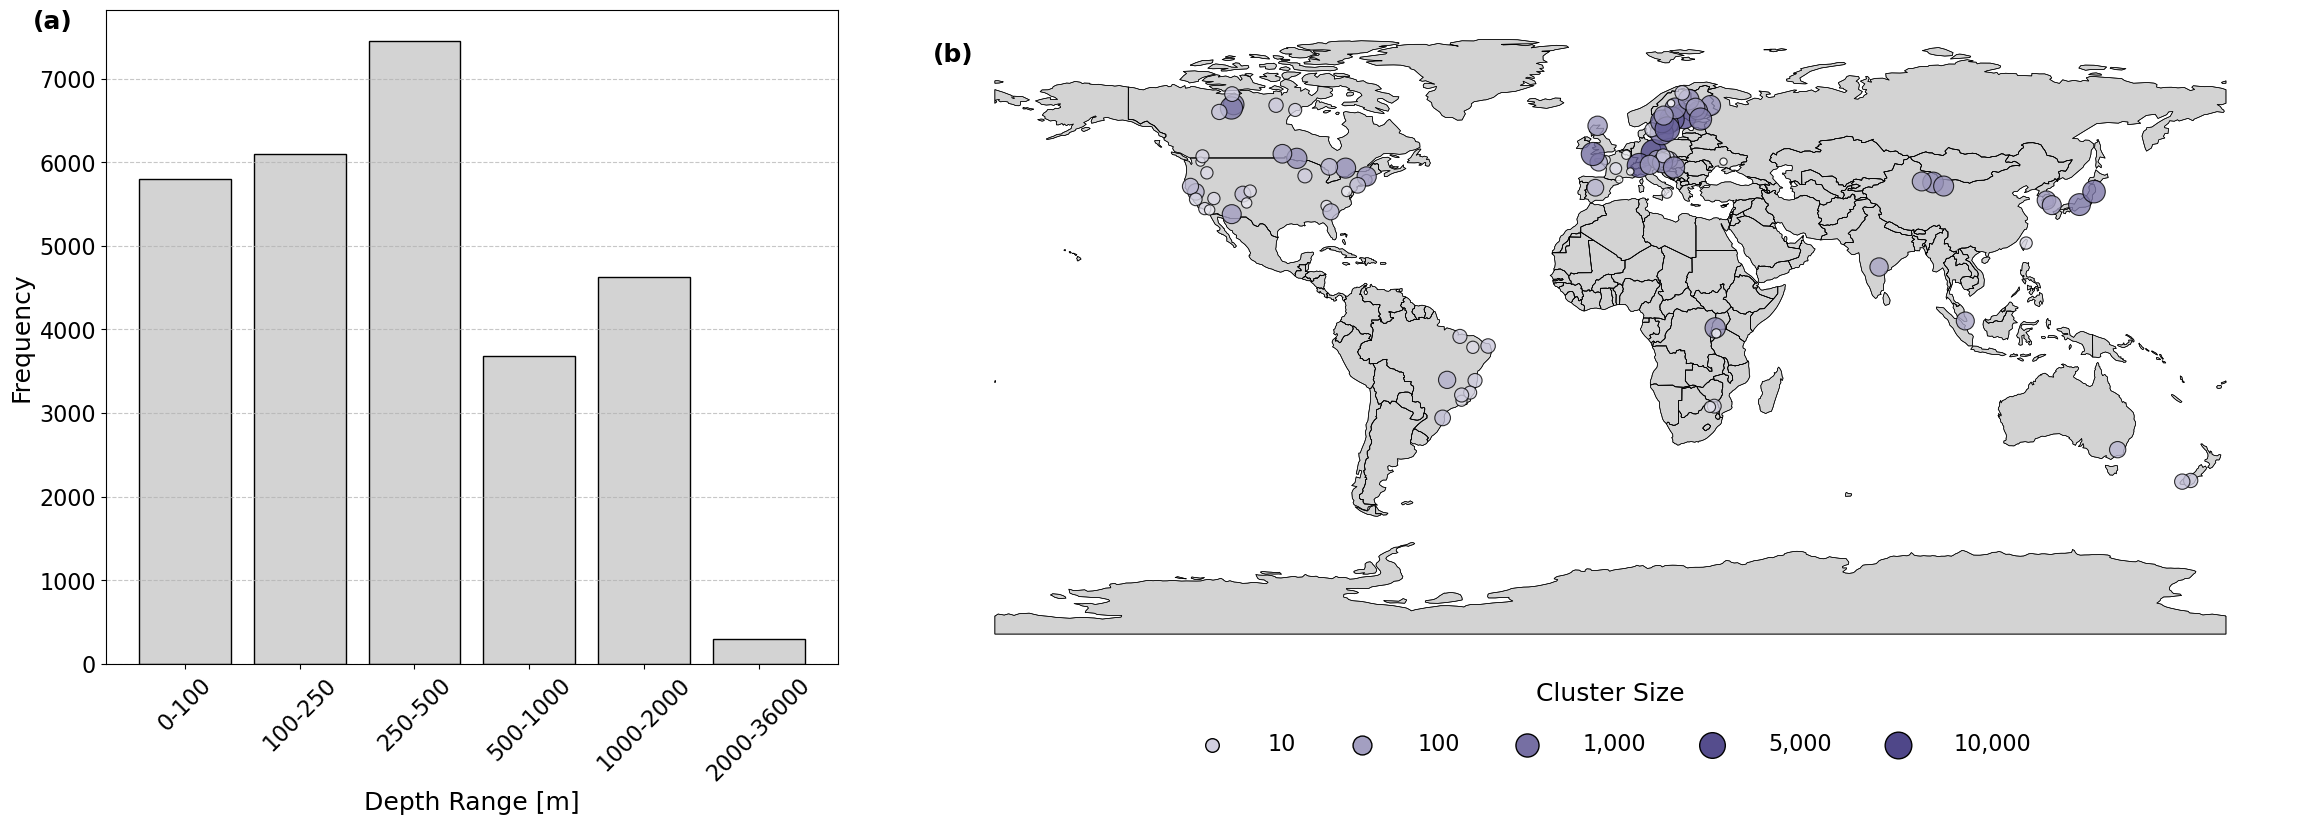

In [78]:
figure_1()

In [79]:
len(df_all[df_all['depth']<=500])/len(df_all)*100

69.24837302438675

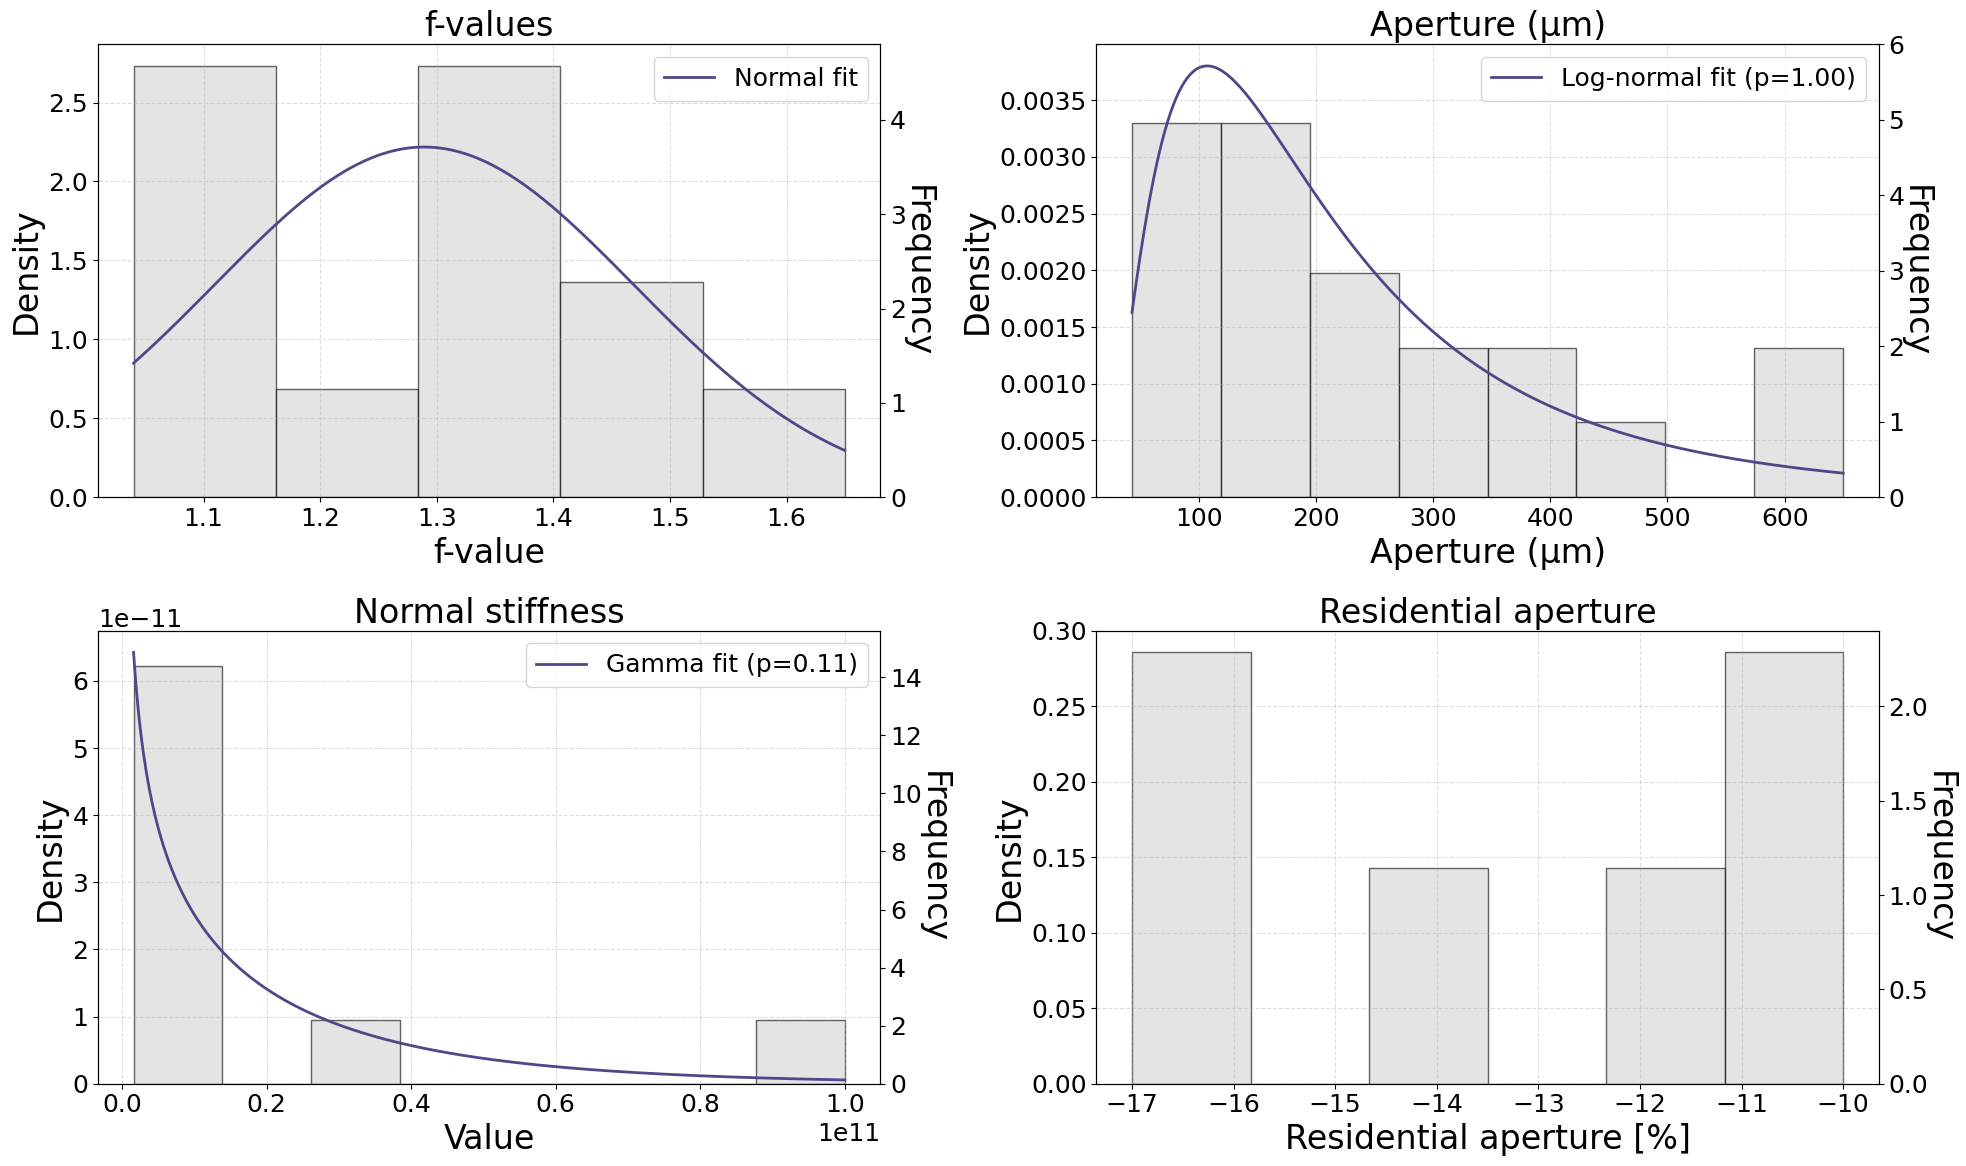

In [80]:



fig, axes = plt.subplots(2, 2, figsize=(20, 12))
(ax1, ax2), (ax3, ax4) = axes

# =============================================================
# Helper function: histogram with dual y-axes (density + counts)
# =============================================================
def dual_axis_hist(ax, data, bins=8):
    """
    Plots density histogram on main axis and frequency on secondary axis.
    Secondary y-axis label is flipped inward.
    """

    # Density histogram (primary axis)
    density_counts, bin_edges, _ = ax.hist(
        data, bins=bins, density=True,
        alpha=0.6, color='lightgray', edgecolor='black'
        # no label here = no "Density" in legend
    )

    # Secondary axis for frequency
    ax2 = ax.twinx()
    raw_counts, _, _ = ax2.hist(
        data, bins=bin_edges, alpha=0.0  # invisible bars for scaling
    )

    # Flip the label so it faces the axis
    ax2.set_ylabel("Frequency", rotation=270, labelpad=20)
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()

    # Set appropriate frequency limits
    ax2.set_ylim(0, max(raw_counts) * 1.2)

    return bin_edges


# =============================================================
# 1) f-values from Witherspoon et al. (1980)
# =============================================================
f_values = np.array([1.21, 1.15, 1.04, 1.49, 1.29, 1.32, 1.45, 1.65,
                     1.1, 1.36, 1.36, 1.05])

bins = dual_axis_hist(ax1, f_values, bins=5)

mean_f = np.mean(f_values)
std_f = np.std(f_values)
x = np.linspace(min(f_values), max(f_values), 200)
ax1.plot(x, norm.pdf(x, mean_f, std_f), "#4F4789", linewidth=2, label="Normal fit")

ax1.set_title("f-values")
ax1.set_xlabel("f-value")
ax1.set_ylabel("Density")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend()

# =============================================================
# 2) Aperture data (log-normal fit)
# =============================================================
aperture_um = np.array([
    360, 176, 166, 205, 64, 145.1, 120, 76.3, 43.1, 262, 627,
    101, 650, 283, 313, 462, 417, 216, 84, 161
])

bins = dual_axis_hist(ax2, aperture_um, bins=8)

params = lognorm.fit(aperture_um)
ks_stat, p_val = kstest(aperture_um, lognorm.cdf, args=params)

x = np.linspace(min(aperture_um), max(aperture_um), 500)
ax2.plot(x, lognorm.pdf(x, *params), "#4F4789", linewidth=2,
         label=f"Log-normal fit (p={p_val:.2f})")

ax2.set_title("Aperture (µm)")
ax2.set_xlabel("Aperture (µm)")
ax2.set_ylabel("Density")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend()

# =============================================================
# 3) Normal stiffness (gamma fit)
# =============================================================
stiffness = np.array([
    1e10, 3.2e9, 3.2e10, 1e11, 3.2e10, 1e11, 1e10, 2e9, 1.6e9, 5e9,
    3.2e9, 1e10, 1.6e9, 2e9, 3.2e9, 1e10, 4e9
])

bins = dual_axis_hist(ax3, stiffness, bins=8)

params = gamma.fit(stiffness, floc=0)
ks_stat, p_val = kstest(stiffness, "gamma", args=params)

x = np.linspace(min(stiffness), max(stiffness), 500)
ax3.plot(x, gamma.pdf(x, *params), "#4F4789", linewidth=2,
         label=f"Gamma fit (p={p_val:.2f})")

ax3.set_title("Normal stiffness")
ax3.set_xlabel("Value")
ax3.set_ylabel("Density")
ax3.grid(True, linestyle="--", alpha=0.4)
ax3.legend()

# =============================================================
# 4) Residential aperture
# =============================================================
res_values = np.array([-10, -12, -11, -14, -16, -17])

bins = dual_axis_hist(ax4, res_values, bins=len(res_values))

ax4.set_title("Residential aperture")
ax4.set_xlabel("Residential aperture [%]")
ax4.set_ylabel("Density")
ax4.grid(True, linestyle="--", alpha=0.4)

# =============================================================
# Save final figure
# =============================================================
plt.tight_layout()
output_path = folder + output_data + "/figS02.png"
plt.savefig(output_path, dpi=900)

plt.show()


### Porosity-depth relationship

In [81]:
spearman_depth_porosity(df_begin, depth_col='depth', porosity_col='porosity')
spearman_depth_porosity(df_all, depth_col='depth', porosity_col='porosity')

✅ Spearman correlation is significant (p = 0.00e+00), correlation coefficient ρ = -0.4662 (negative relationship)
✅ Spearman correlation is significant (p = 0.00e+00), correlation coefficient ρ = -0.4574 (negative relationship)


In [82]:
#formulas fitted 
slope_begin,intercept_begin = porosity_formula(df_begin)
print("\n")
slope_all,intercept_all =porosity_formula(df_all)

Linear Fit Formula: log10(porosity) = -1.1632 * log10(depth) + -3.1842
Porosity = 10**(-3.1842) * depth**(-1.1632)
R² = 0.17
porosity = 10**(-3.18) * depth**(-1.16)


Linear Fit Formula: log10(porosity) = -1.1218 * log10(depth) + -3.2710
Porosity = 10**(-3.2710) * depth**(-1.1218)
R² = 0.17
porosity = 10**(-3.27) * depth**(-1.12)


In [83]:
valid_point_graph(df_begin)
print("\n")

valid_point_graph(df_all)


Depth low = 1.50
end run


Depth low = 1.50
end run


In [84]:
def porosity_formula_diff(slope_begin, intercept_begin, z_nieuw, z_oud):
    z_v_nieuw = 10**(intercept_begin) * z_nieuw**(slope_begin)
    z_v_oud = 10**(intercept_begin) * z_oud**(slope_begin)
    diff= (z_v_nieuw-z_v_oud)/z_v_oud
    print(f"{diff*100:.2f}")

porosity_formula_diff(slope_begin, intercept_begin, 500, 250)
porosity_formula_diff(slope_begin, intercept_begin, 1250, 1000)

-55.35
-22.86


In [85]:

model = smf.ols("np.log(porosity) ~ depth", data=df_begin).fit()
print(model.rsquared, model.params)


0.17528726313659737 Intercept   -12.323716
depth        -0.003201
dtype: float64


Linear Fit Formula: log10(porosity) = -1.1632 * log10(depth) + -3.1842
Porosity = 10**(-3.1842) * depth**(-1.1632)
R² = 0.17
Linear Fit Formula: log10(porosity) = -1.1218 * log10(depth) + -3.2710
Porosity = 10**(-3.2710) * depth**(-1.1218)
R² = 0.17


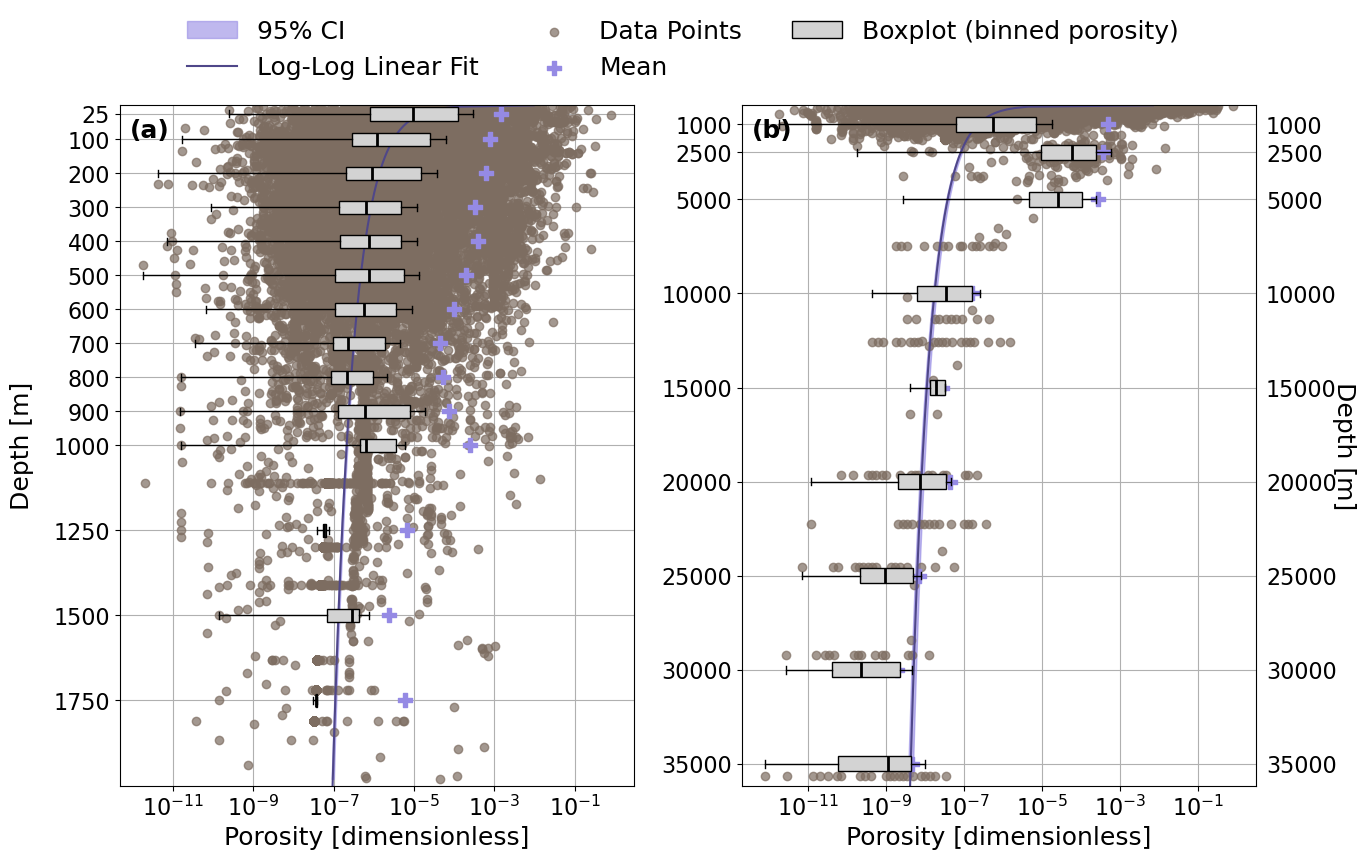

In [86]:
results = plot_porosity_vs_depth(
    df_list=[df_begin, df_all],
    bin_edges_list=[
        [0.0, 50, 150, 250, 350, 450, 550, 650, 750, 850, 950, 1050, 1450, 1550, 1950],
        [0.0, 2000, 3000, 7000, 13000.0, 17000, 23000.0, 27000, 33000, 37000]
    ],
    widths_list=[40, 800],
    depth_max_list=[2000, df_all['depth'].max() + 500],
    output_path="figure01.png",
    folder=folder,
    output_data=output_data
)


In [87]:
#excluide top 1000 meters
df_below1000=df[df['depth']<=deep_point*1000].copy()
df_below1000=df_below1000[df_below1000['depth']>1000]
spearman_depth_porosity(df_below1000, depth_col='depth', porosity_col='porosity')

✅ Spearman correlation is significant (p = 0.00e+00), correlation coefficient ρ = -0.7947 (negative relationship)


In [88]:
# results = plot_porosity_vs_depth(
#     df_list=[df_below1000, df_all],
#     bin_edges_list=[
#         [0.0, 50, 150, 250, 350, 450, 550, 650, 750, 850, 950, 1050, 1450, 1550, 1950],
#         [0.0, 2000, 3000, 7000, 13000.0, 17000, 23000.0, 27000, 33000, 37000]
#     ],
#     widths_list=[40, 800],
#     depth_max_list=[2000, df_all['depth'].max() + 500],
#     output_path="figure01.png",
#     folder=folder,
#     output_data=output_data
# )


In [89]:
results_df, all_samples_df,all_samples_array = calculate_uncertainty(df)

In [90]:
results_df_begin, all_samples_df_begin,all_samples_array_begin=calculate_uncertainty(df_begin)
results_df_all, all_samples_df,all_samples_array_all=calculate_uncertainty(df_all)

IQR_begin_mcall, median_begin_mcall, lower_begin_mcall, upper_begin_mcall=calculate_IQR_monte_carlo_all(all_samples_df_begin)
IQR_all_mcall, median_all_mcall, lower_all_mcall, upper_all_mcall=calculate_IQR_monte_carlo_all(all_samples_df)

all_samples_df_begin=all_samples_df[all_samples_df['depth']<=deep_point*1000]
row_df_begin_single,row_clean_begin_single,lower_begin_single,upper_begin_single,median_begin_single,IQR_begin_single = calculate_IQR_monte_carlo_single(all_samples_df_begin)
row_df_all_single,row_clean_all_single,lower_all_single,upper_all_single,median_all_single,IQR_all_single = calculate_IQR_monte_carlo_single(all_samples_df)


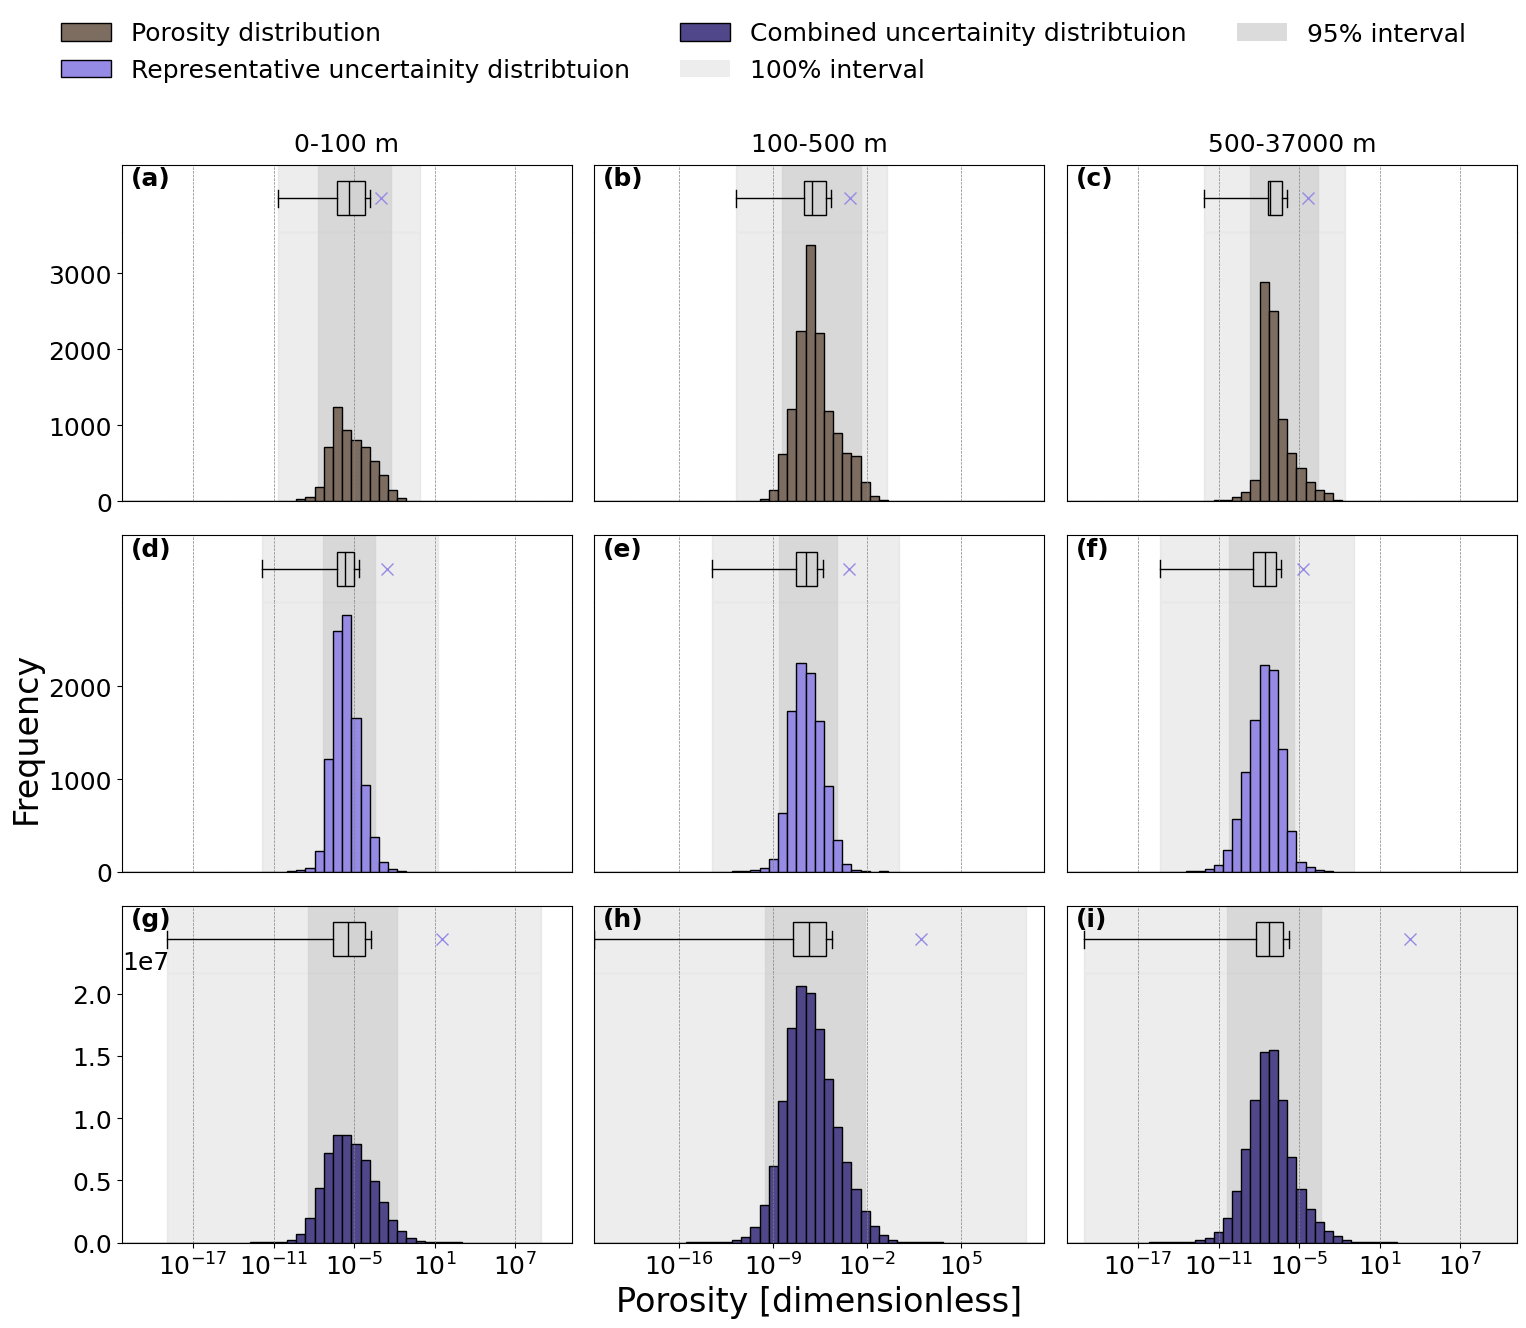

In [91]:
def gather_distribution_stats(values, label):
    
    stats = {
        "label": label,
        "count": len(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "std": np.std(values),
        "min": np.min(values),
        "max": np.max(values),
        "Q1": np.percentile(values, 25),
        "Q3": np.percentile(values, 75),
        "2.5%": np.percentile(values, 2.5),
        "97.5%": np.percentile(values, 97.5)
    }
    return stats


def plot_3x3_histograms_with_boxplots(df_all, all_samples_df, depth_intervals, calculate_IQR_monte_carlo_single):


    evc = '#7D6D61'
    svc = '#958AE4'
    avc = '#4F4789'

    evt = "Porosity distribution"
    svt = "Representative uncertainity distribtuion"
    avt = "Combined uncertainity distribtuion"

    all_stats = []

    fig = plt.figure(figsize=(18, 14))
    outer_grid = gridspec.GridSpec(3, 3, wspace=0.05, hspace=0.1)

    all_values = all_samples_df.drop(columns='depth').values.flatten()
    all_values = all_values[~np.isnan(all_values)]
    all_values = all_values[all_values > 0]
    common_bin_edges = np.logspace(np.log10(all_values.min()), np.log10(all_values.max()), 50)

    hist_axes_by_row = [None] * 3

    for col_idx, (depth_min, depth_max) in enumerate(depth_intervals):
        mc_input_df = all_samples_df[(all_samples_df['depth'] >= depth_min) & (all_samples_df['depth'] < depth_max)]
        samples_df_filtered = mc_input_df.drop(columns=['depth'])

        raw_values = df_all[(df_all['depth'] >= depth_min) & (df_all['depth'] < depth_max)]['porosity'].dropna()
        _, row_clean_all_single, *_ = calculate_IQR_monte_carlo_single(mc_input_df)
        cleaned_values = row_clean_all_single.to_numpy().flatten()
        cleaned_values = cleaned_values[cleaned_values > 0]

        sample_values = samples_df_filtered.values.flatten()
        sample_values = sample_values[~np.isnan(sample_values)]
        sample_values = sample_values[sample_values > 0]

        data_rows = [
            (raw_values, evc, evt, "Raw Porosity"),
            (cleaned_values, svc, svt, "Cleaned MC"),
            (sample_values, avc, avt, "All MC Samples")
        ]

        for row_idx, (values, color, label, row_label) in enumerate(data_rows):
            cell = outer_grid[row_idx, col_idx]
            inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=cell, height_ratios=[1, 4], hspace=0)

            ax_box = fig.add_subplot(inner_grid[0])
            ax_box.boxplot(
                values, vert=False, widths=0.5,
                patch_artist=True, showfliers=False,
                boxprops=dict(facecolor='lightgrey', color='black'),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black')
            )
            mean_val = np.mean(values)
            ax_box.plot(mean_val, 1, marker='x', color='#958AE4', markersize=8)
            p0, p100 = np.percentile(values, [0, 100])
            p2_5, p97_5 = np.percentile(values, [2.5, 97.5])
            ax_box.axvspan(p0, p100, color='lightgrey', alpha=0.4, zorder=0)
            ax_box.axvspan(p2_5, p97_5, color='lightgrey', alpha=0.8, zorder=0)

            ax_box.set_xlim(common_bin_edges[0], common_bin_edges[-1])
            ax_box.set_xscale('log')
            ax_box.set_yticks([])
            ax_box.grid(True, which='both', axis='x', linestyle='--', linewidth=0.5, color='gray')

            if col_idx != 0:
                ax_box.tick_params(left=False, labelleft=False)

            if row_idx == 0:
                ax_box.set_title(f"{depth_min}-{depth_max} m", fontsize=18, pad=10)

            # Hide bottom x-axis of boxplot
            ax_box.spines['bottom'].set_visible(False)
            ax_box.tick_params(bottom=False, labelbottom=False)

            share_ax = hist_axes_by_row[row_idx] if col_idx > 0 else None
            ax_hist = fig.add_subplot(inner_grid[1], sharey=share_ax)
            if col_idx == 0:
                hist_axes_by_row[row_idx] = ax_hist

            ax_hist.hist(
                values, bins=common_bin_edges,
                color=color, edgecolor='black', log=False, label=label
            )
            ax_hist.axvspan(p0, p100, color='lightgrey', alpha=0.4, zorder=0)
            ax_hist.axvspan(p2_5, p97_5, color='lightgrey', alpha=0.8, zorder=0)

            ax_hist.set_xscale('log')
            ax_hist.set_xlim(common_bin_edges[0], common_bin_edges[-1])
            ax_hist.grid(True, which='both', axis='x', linestyle='--', linewidth=0.5, color='gray')

            if row_idx != 2:
                ax_hist.tick_params(bottom=False, labelbottom=False)
            if col_idx != 0:
                ax_hist.tick_params(left=False, labelleft=False)

            # Hide top x-axis of histogram
            ax_hist.spines['top'].set_visible(False)

            if (row_idx == 2) and (col_idx == 1):
                ax_hist.set_xlabel("Porosity [dimensionless]")

            if (col_idx == 0) and (row_idx == 1):
                ax_hist.set_ylabel("Frequency")

            all_stats.append(gather_distribution_stats(values, f"{row_label} ({depth_min}–{depth_max} m)"))

            # Subplot letter labels (a, b, c, ...)
            label_idx = row_idx * 3 + col_idx
            label_letter = chr(ord('a') + label_idx)
            ax_box.text(
                0.02, 0.8, f"({label_letter})",
                transform=ax_box.transAxes,
                fontsize=18,
                fontweight='bold',
                verticalalignment='center'
            )


    stats_df = pd.DataFrame(all_stats)

    handles = [
        Patch(facecolor=evc, edgecolor='black', label=evt),
        Patch(facecolor=svc, edgecolor='black', label=svt),
        Patch(facecolor=avc, edgecolor='black', label=avt),
        Patch(facecolor='lightgrey', alpha=0.4, label='100% interval'),
        Patch(facecolor='lightgrey', alpha=0.8, label='95% interval')
    ]
    legend = fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=18, frameon=True)
    legend.get_frame().set_edgecolor('None')
    legend.get_frame().set_facecolor('none')

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(f"{folder}{output_data}/fig02.png", dpi=900, bbox_inches='tight',transparent=True)
    plt.show()

    return all_stats,stats_df
    
# Call the function
depth_ranges = [(0, 100), (100, 500), (500, 37000)]
all_stats,stats_df=plot_3x3_histograms_with_boxplots(df_all, all_samples_df, depth_ranges, calculate_IQR_monte_carlo_single)



In [92]:


def plot_3x3_histograms_with_boxplots(df_all, all_samples_df, depth_intervals, calculate_IQR_monte_carlo_single):
   
    for col_idx, (depth_min, depth_max) in enumerate(depth_intervals):
        # Filter for depth interval
        mc_input_df = all_samples_df[(all_samples_df['depth'] >= depth_min) & (all_samples_df['depth'] < depth_max)]
        print((depth_min, depth_max))
       

        # --- Row 1: Raw Porosity (df_all) ---
        filtered_df_all = df_all[(df_all['depth'] >= depth_min) & (df_all['depth'] < depth_max)]
        porosity_values = filtered_df_all['porosity'].dropna()
        print('estimations')
        test_distributions_print(porosity_values, alpha=0.05, test='simple')
        print('\n')
        # --- Row 2: Monte Carlo Cleaned Data ---
        _, row_clean_all_single, _, _, _, _ = calculate_IQR_monte_carlo_single(mc_input_df)
        cleaned_values = row_clean_all_single.to_numpy().flatten()
        cleaned_values = cleaned_values[cleaned_values > 0]

        print('single')
        test_distributions_print(cleaned_values, alpha=0.05, test='simple')
        print('\n')

        # --- Row 3: All Monte Carlo Samples ---
        samples_df_filtered = mc_input_df.drop(columns=['depth'])
        sample_values = samples_df_filtered.values.flatten()
        sample_values = sample_values[~np.isnan(sample_values)]
        sample_values = sample_values[sample_values > 0]

        print('Monte Carlo')
        test_distributions_print(sample_values, alpha=0.05, test='simple')
        print('\n')


# Call the function
depth_ranges = [(0, 100), (100, 500), (500, 37000)]
plot_3x3_histograms_with_boxplots(df_all, all_samples_df, depth_ranges, calculate_IQR_monte_carlo_single)


(0, 100)
estimations
Right-skewed (positively skewed)


single
Right-skewed (positively skewed)


Monte Carlo
Right-skewed (positively skewed)


(100, 500)
estimations
Right-skewed (positively skewed)


single
Right-skewed (positively skewed)


Monte Carlo
Right-skewed (positively skewed)


(500, 37000)
estimations
Right-skewed (positively skewed)


single
Right-skewed (positively skewed)


Monte Carlo
Right-skewed (positively skewed)




In [93]:
stats_df = pd.DataFrame(all_stats)
stats_df.rename(columns={
    "mean": "Mean",
    "median": "Median",
    "2.5%": "Q2.5",
    "97.5%": "Q97.5",
    "min": "Min",
    "max": "Max"
}, inplace=True)


def print_summary_ratios(stats_df):
    def get_stats(label):
        # Use the correct column name here
        return stats_df[stats_df["label"].str.startswith(label)].reset_index(drop=True)

    raw = get_stats("Raw Porosity")
    cleaned = get_stats("Cleaned MC")
    all_samples = get_stats("All MC Samples")

    depth_labels = ["0–100", "100–500", "500–37000"]

    print("1. Raw Porosity (0–100 m):")
    median_0 = raw.loc[0, "Median"]
    mean_0 = raw.loc[0, "Mean"]
    iqr_0 = raw.loc[0, "Q3"] - raw.loc[0, "Q1"]
    print(f"   - Median       = {median_0:.2e}")
    print(f"   - Mean         = {mean_0:.2e}")
    print(f"   - Mean/Median  = {mean_0/median_0:.2f}")
    print(f"   - IQR          = {iqr_0:.2e}")

    # -----------------------------
    # IQRs for all depths
    # -----------------------------
    print("\n   Absolute IQR for all depth intervals:")
    for i, depth in enumerate(depth_labels):
        iqr = raw.loc[i, "Q3"] - raw.loc[i, "Q1"]
        print(f"     Depth {depth}: IQR = {iqr:.2e}")

    # -----------------------------
    # Median/Mean ratios for all depths
    # -----------------------------
    print("\n   Median/Mean ratios for all depth intervals:")
    for i, depth in enumerate(depth_labels):
        median = raw.loc[i, "Median"]
        mean = raw.loc[i, "Mean"]
        print(f"     Depth {depth}: Median/Mean = {median/mean:.2e}")

    # -----------------------------
    # Cleaned MC IQR vs Raw Porosity IQR
    # -----------------------------
    print("\n2. Cleaned MC IQR vs Raw Porosity IQR:")
    print("   Absolute IQR:")
    for i, depth in enumerate(depth_labels):
        iqr_cleaned = cleaned.loc[i, "Q3"] - cleaned.loc[i, "Q1"]
        print(f"     Depth {depth}: Cleaned IQR = {iqr_cleaned:.2e}")

    print("   IQR Ratio (Cleaned / Raw):")
    for i, depth in enumerate(depth_labels):
        iqr_cleaned = cleaned.loc[i, "Q3"] - cleaned.loc[i, "Q1"]
        iqr_raw = raw.loc[i, "Q3"] - raw.loc[i, "Q1"]
        print(f"     Depth {depth}: {iqr_cleaned/iqr_raw:.2f}")

    # -----------------------------
    # All MC Samples Comparison
    # -----------------------------
    print("\n3. All MC Samples Comparison:")

    # Increase in mean for 0-100 m
    mean_raw_0 = raw.loc[0, "Mean"]
    mean_mc_0 = all_samples.loc[0, "Mean"]
    increase_mean = mean_mc_0 - mean_raw_0
    print(f"   Depth 0–100 m: Increase in mean vs Raw Porosity = {increase_mean:.2e}")

    # Mean ratios for all depths
    print("\n   Mean ratios (MC/Raw) for all depths:")
    for i, depth in enumerate(depth_labels):
        mean_mc = all_samples.loc[i, "Mean"]
        mean_raw = raw.loc[i, "Mean"]
        print(f"     Depth {depth}: {mean_mc/mean_raw:.2f}")

    # Median ratios for all depths
    print("\n   Median ratios (MC/Raw) for all depths:")
    for i, depth in enumerate(depth_labels):
        median_mc = all_samples.loc[i, "Median"]
        median_raw = raw.loc[i, "Median"]
        print(f"     Depth {depth}: {median_mc/median_raw:.2f}")

    # IQR increases for all depths
    print("\n   IQR increases (MC - Raw) and % increase:")
    for i, depth in enumerate(depth_labels):
        iqr_mc = all_samples.loc[i, "Q3"] - all_samples.loc[i, "Q1"]
        iqr_raw = raw.loc[i, "Q3"] - raw.loc[i, "Q1"]
        delta = iqr_mc - iqr_raw
        print(f"     Depth {depth}: {delta:.2e} ({delta/iqr_raw*100:.2f}%)")

    print()  # extra newline for clarity


print_summary_ratios(stats_df)

1. Raw Porosity (0–100 m):
   - Median       = 3.95e-06
   - Mean         = 1.03e-03
   - Mean/Median  = 260.01
   - IQR          = 6.12e-05

   Absolute IQR for all depth intervals:
     Depth 0–100: IQR = 6.12e-05
     Depth 100–500: IQR = 8.57e-06
     Depth 500–37000: IQR = 5.22e-07

   Median/Mean ratios for all depth intervals:
     Depth 0–100: Median/Mean = 3.85e-03
     Depth 100–500: Median/Mean = 1.42e-03
     Depth 500–37000: Median/Mean = 1.27e-03

2. Cleaned MC IQR vs Raw Porosity IQR:
   Absolute IQR:
     Depth 0–100: Cleaned IQR = 9.91e-06
     Depth 100–500: Cleaned IQR = 2.04e-06
     Depth 500–37000: Cleaned IQR = 1.71e-07
   IQR Ratio (Cleaned / Raw):
     Depth 0–100: 0.16
     Depth 100–500: 0.24
     Depth 500–37000: 0.33

3. All MC Samples Comparison:
   Depth 0–100 m: Increase in mean vs Raw Porosity = 3.69e+01

   Mean ratios (MC/Raw) for all depths:
     Depth 0–100: 35964.30
     Depth 100–500: 209698.13
     Depth 500–37000: 40400659.31

   Median ratios (

### Statistical tests

In [94]:
#df.to_csv("/Users/uib/Documents/Project_1/Python_scripts/output_data/df_16-7-2025.csv", index=False)
df_stats = pd.read_csv("/Users/uib/Documents/1.PhD-project/Paper1/Project_1/QGIS/Influencing_factors_QGIS/Porosity_plate_boundaries_setting.csv")

In [95]:
#type of rock
df_stats = df_stats.rename(columns={'category': 'rock_type'})
df_stats = df_stats.rename(columns={'type': 'plate_boundary_type'})
df_stats = df_stats.rename(columns={'prov_type_min': 'tectonic_setting'})

In [96]:
# Define the columns you want to keep
columns_to_keep = ['porosity', 'source','depth', 'latitude', 'longitude', 'rock_type', 'tectonic_setting', 'plate_boundary_type', 'distance']

# Print original length
print("🔢 Original number of rows:", len(df))

# Create cleaned DataFrame
df_clean = df_stats[columns_to_keep].dropna()

# Print cleaned length
print("✅ Number of rows after dropping NaNs:", len(df_clean))
print(len(df_clean)/len(df_all)*100)

🔢 Original number of rows: 27966
✅ Number of rows after dropping NaNs: 27393
97.9510834584853


### New statistics

In [97]:
def holm_bonferroni(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    p_sorted = np.array(pvals)[order]
    adj_sorted = np.zeros(m)
    running_max = 0.0
    for i in range(m):
        adj_i = (m - i) * p_sorted[i]
        running_max = max(running_max, adj_i)
        adj_sorted[i] = min(1.0, running_max)
    adj = np.empty(m)
    adj[order] = adj_sorted
    return adj

def mw_two_sided_stats(x, y):
 
    res = mannwhitneyu(x, y, alternative='two-sided', method='asymptotic')
    p = float(res.pvalue)

    n1, n2 = len(x), len(y)
    all_vals = np.concatenate([x, y])
    ranks = rankdata(all_vals)
    r1 = ranks[:n1].sum()
    U1 = r1 - n1 * (n1 + 1) / 2.0

    # Cliff's delta: δ in [-1, 1]; positive if x tends to be larger than y
    delta = 2.0 * U1 / (n1 * n2) - 1.0
    med_diff = float(np.median(x) - np.median(y))  # x - y
    return U1, p, delta, med_diff

In [98]:

def analyze_porosity_depth_by_group(
    df_clean,
    group_col="rock_type",
    min_n_keep=150,
    alpha=0.05,
    adjust_for_depth=True,   # set True to run one-vs-all on depth-adjusted residuals
    do_pairwise=False,         # (unused here) keep False; one-vs-all answers your question
    output_path="fig.png"
):
    # -------------------------------------------------

    # -------------------------------------------------
    # Utilities: multiple comparisons & effect sizes
    # -------------------------------------------------
    def holm_bonferroni(pvals):
        """Holm step-down adjusted p-values (controls FWER)."""
        m = len(pvals)
        if m == 0:
            return np.array([])
        order = np.argsort(pvals)
        p_sorted = np.array(pvals)[order]
        adj_sorted = np.zeros(m)
        running_max = 0.0
        for i in range(m):
            adj_i = (m - i) * p_sorted[i]
            running_max = max(running_max, adj_i)
            adj_sorted[i] = min(1.0, running_max)
        adj = np.empty(m)
        adj[order] = adj_sorted
        return adj

    def mw_two_sided_stats(x, y):
        """
        Mann-Whitney U (two-sided p), plus Cliff's delta and median difference.
        Uses asymptotic p-value for speed on large samples.
        """
        res = mannwhitneyu(x, y, alternative='two-sided', method='asymptotic')
        p = float(res.pvalue)

        n1, n2 = len(x), len(y)
        all_vals = np.concatenate([x, y])
        ranks = rankdata(all_vals)
        r1 = ranks[:n1].sum()
        U1 = r1 - n1 * (n1 + 1) / 2.0

        # Cliff's delta: δ in [-1, 1]; positive if x tends to be larger than y
        delta = 2.0 * U1 / (n1 * n2) - 1.0
        med_diff = float(np.median(x) - np.median(y))  # x - y
        return U1, p, delta, med_diff

    def cliffs_magnitude(delta):
        ad = abs(delta)
        if ad < 0.147:
            return "negligible"
        elif ad < 0.33:
            return "small"
        elif ad < 0.474:
            return "medium"
        else:
            return "large"

    # -------------------------------------------------
    # Step 1: Clean data and merge small categories
    # -------------------------------------------------
    df = df_clean.copy()

    df = df.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["porosity", "depth", group_col]
    )
    df = df[(df["porosity"] > 0) & (df["depth"] > 0)]
    df[group_col] = df[group_col].astype("category")

    counts = df[group_col].value_counts()
    small_types = counts[counts < min_n_keep].index.tolist()

    if small_types:
        df[group_col] = df[group_col].apply(
            lambda x: "other" if x in small_types else x
        )
        df[group_col] = df[group_col].astype("category")

    # Recompute counts and cached lists after merging
    counts = df[group_col].value_counts()
    groups_list = list(df[group_col].cat.categories)

    # -------------------------------------------------
    # Step 0: Does group_col influence porosity at all? (ignoring depth)
    # -------------------------------------------------
    if len(groups_list) < 2:
        warn("Only one group present after merging; skipping group comparisons.")
        kw_stat, kw_p = np.nan, np.nan
    else:
        groups_data = [df.loc[df[group_col] == g, "porosity"].values for g in groups_list]
        kw_stat, kw_p = kruskal(*groups_data)
        print("\n=== Does grouping affect porosity (ignoring depth)? ===")
        print(f"Kruskal–Wallis H = {kw_stat:.2f}, p = {kw_p:.4g}")
        if kw_p < alpha:
            print(f"Conclusion: YES — '{group_col}' influences porosity distributions overall.")
        else:
            print(f"Conclusion: NO — no evidence that '{group_col}' affects porosity overall.")

    # -------------------------------------------------
    # Step 0b: One-vs-all on porosity (who contributes? ignoring depth)
    # -------------------------------------------------
    print("\n=== Which groups contribute to porosity (one-vs-all on porosity) ===")
    ova_rows, ova_pvals = [], []
    if len(groups_list) >= 2:
        for g in groups_list:
            x = df.loc[df[group_col] == g, "porosity"].values
            y = df.loc[df[group_col] != g, "porosity"].values
            if len(x) == 0 or len(y) == 0:
                continue
            U1, p, delta, med_diff = mw_two_sided_stats(x, y)
            ova_rows.append({
                "group": g,
                "n_group": int(len(x)),
                "n_rest": int(len(y)),
                "median_group": float(np.median(x)),
                "median_rest": float(np.median(y)),
                "median_diff": med_diff,          # group - rest
                "cliffs_delta": delta,            # [-1,1]
                "p_raw": p
            })
            ova_pvals.append(p)

    if ova_rows:
        p_adj = holm_bonferroni(ova_pvals)
        for row, padj in zip(ova_rows, p_adj):
            row["p_adj_holm"] = float(padj)
            row["significant"] = bool(padj < alpha)

        # Sort by adjusted p for readability
        ova_rows_sorted = sorted(ova_rows, key=lambda r: r["p_adj_holm"])

        # Human-friendly summary lines
        for r in ova_rows_sorted:
            dir_arrow = "↑" if r["cliffs_delta"] > 0 else ("↓" if r["cliffs_delta"] < 0 else "→")
            eff_label = cliffs_magnitude(r["cliffs_delta"])
            if r["significant"]:
                print(
                    f"  {r['group']}: {dir_arrow} porosity vs rest (Holm p={r['p_adj_holm']:.4g}) — "
                    f"Δmedian={r['median_diff']:.4g} "
                    f"(group {r['median_group']:.4g} vs rest {r['median_rest']:.4g}), "
                    f"Cliff’s δ={r['cliffs_delta']:.3f} ({eff_label})."
                )
            else:
                print(
                    f"  {r['group']}: no clear difference (Holm p={r['p_adj_holm']:.4g}) — "
                    f"Δmedian={r['median_diff']:.4g}, Cliff’s δ={r['cliffs_delta']:.3f} ({eff_label})."
                )

        # Quick recap
        sig_labels = [r['group'] for r in ova_rows if r['significant']]
        if sig_labels:
            print("Summary: significant contributors (ignoring depth):", ", ".join(sig_labels))
        else:
            print("Summary: no groups differ from the rest at α =", alpha)
    else:
        print("  Not enough groups or data to compute one-vs-all comparisons.")

    # -------------------------------------------------
    # Step 0c (optional): Depth-adjusted one-vs-all via residuals
    # -------------------------------------------------
    if adjust_for_depth and len(groups_list) >= 2:
        # Overall log-log model (no groups) to remove depth trend
        mod_overall = smf.ols("np.log10(porosity) ~ np.log10(depth)", data=df).fit(cov_type="HC3")
        df["resid_overall"] = np.log10(df["porosity"]) - (
            mod_overall.params["Intercept"]
            + mod_overall.params["np.log10(depth)"] * np.log10(df["depth"])
        )

        print("\n=== Which groups contribute after controlling for depth (one-vs-all on residuals) ===")
        rows_resid, pvals_resid = [], []
        for g in groups_list:
            x = df.loc[df[group_col] == g, "resid_overall"].values
            y = df.loc[df[group_col] != g, "resid_overall"].values
            if len(x) == 0 or len(y) == 0:
                continue
            U1, p, delta, med_diff = mw_two_sided_stats(x, y)
            rows_resid.append({
                "group": g,
                "n_group": int(len(x)),
                "n_rest": int(len(y)),
                "median_resid_group": float(np.median(x)),
                "median_resid_rest": float(np.median(y)),
                "median_resid_diff": med_diff,  # group - rest
                "cliffs_delta": delta,
                "p_raw": p
            })
            pvals_resid.append(p)

        if rows_resid:
            p_adj = holm_bonferroni(pvals_resid)
            for r, padj in zip(rows_resid, p_adj):
                r["p_adj_holm"] = float(padj)
                r["significant"] = bool(padj < alpha)

            rows_resid_sorted = sorted(rows_resid, key=lambda r: r["p_adj_holm"])

            for r in rows_resid_sorted:
                dir_arrow = "↑" if r["cliffs_delta"] > 0 else ("↓" if r["cliffs_delta"] < 0 else "→")
                eff_label = cliffs_magnitude(r["cliffs_delta"])
                if r["significant"]:
                    print(
                        f"  {r['group']}: {dir_arrow} porosity than expected at given depth (Holm p={r['p_adj_holm']:.4g}) — "
                        f"Δmedian(resid)={r['median_resid_diff']:.4g} "
                        f"(group {r['median_resid_group']:.4g} vs rest {r['median_resid_rest']:.4g}), "
                        f"Cliff’s δ={r['cliffs_delta']:.3f} ({eff_label})."
                    )
                else:
                    print(
                        f"  {r['group']}: no clear depth-adjusted difference (Holm p={r['p_adj_holm']:.4g}) — "
                        f"Δmedian(resid)={r['median_resid_diff']:.4g}, "
                        f"Cliff’s δ={r['cliffs_delta']:.3f} ({eff_label})."
                    )

            sig_labels = [r['group'] for r in rows_resid if r['significant']]
            if sig_labels:
                print("Summary: significant depth-adjusted contributors:", ", ".join(sig_labels))
            else:
                print("Summary: no groups differ from the rest after controlling for depth at α =", alpha)
        else:
            print("  Not enough data to compute depth-adjusted one-vs-all comparisons.")

    # -------------------------------------------------
    # Depth-related analysis description
    # -------------------------------------------------
    print("\n=== What is being tested (depth-related) ===")
    print(
        f"We test whether the porosity–depth relationship differs by '{group_col}'.\n"
        f"Each {group_col} is allowed its own intercept and its own log10(depth) slope.\n"
        "We test both global and group-specific differences."
    )

  

    # -------------------------------------------------
    # Step 2: Per-group OLS model (no global intercept)
    # -------------------------------------------------
    formula = (
        f"np.log10(porosity) ~ -1 + C({group_col}) "
        f"+ C({group_col}):np.log10(depth)"
    )

    mod = smf.ols(formula, data=df).fit(cov_type="HC3")

    print("\n=== Model fit ===")
    print(f"R-squared: {mod.rsquared:.3f}")
    print(f"Adjusted R-squared: {mod.rsquared_adj:.3f}")

    # -------------------------------------------------
    # Step 3: Global Wald test (intercepts + slopes)
    # -------------------------------------------------
    param_names = mod.params.index.tolist()

    intercepts, slopes = {}, {}
    for p in param_names:
        m_i = re.match(rf"C\({group_col}\)\[(.+)\]$", p)
        m_s = re.match(rf"C\({group_col}\)\[(.+)\]:np.log10\(depth\)$", p)
        if m_i:
            intercepts[m_i.group(1)] = p
        if m_s:
            slopes[m_s.group(1)] = p

    groups = sorted(intercepts.keys())

    # Build contrasts vs an arbitrary pivot (for constraints only; does NOT add a baseline)
    ref = groups[0]
    R_rows = []
    # Intercepts equalities
    for g in groups[1:]:
        r = np.zeros(len(param_names))
        r[param_names.index(intercepts[g])] = 1
        r[param_names.index(intercepts[ref])] = -1
        R_rows.append(r)
    # Slopes equalities
    for g in groups[1:]:
        r = np.zeros(len(param_names))
        r[param_names.index(slopes[g])] = 1
        r[param_names.index(slopes[ref])] = -1
        R_rows.append(r)

    R = np.vstack(R_rows)
    wald_global = mod.wald_test(R)
    p_global = float(wald_global.pvalue)

    print("\n=== Global Wald test (intercepts + slopes) ===")
    print(f"χ² = {float(wald_global.statistic):.2f}, p = {p_global:.4g}")
    if p_global < alpha:
        print(f"Conclusion: YES — '{group_col}' significantly affects the porosity–depth relationship.")
    else:
        print(f"Conclusion: NO — no statistical evidence that '{group_col}' matters for the depth relationship.")

    # -------------------------------------------------
    # Step 4: One-vs-all Wald tests (slopes)
    # -------------------------------------------------
    def joint_diff_test(param_ref, param_others):
        P = len(param_names)
        R = np.zeros((len(param_others), P))
        for i, p in enumerate(param_others):
            R[i, param_names.index(param_ref)] = 1
            R[i, param_names.index(p)] = -1
        return mod.wald_test(R)

    slope_sig = {}
    for g in groups:
        others = [x for x in groups if x != g]
        w = joint_diff_test(slopes[g], [slopes[o] for o in others])
        slope_sig[g] = float(w.pvalue) < alpha

    sig_groups = [g for g, v in slope_sig.items() if v]
    nonsig_groups = [g for g, v in slope_sig.items() if not v]

    print("\n=== Group-specific slope significance (vs all others) ===")
    print("Statistically significant:")
    print("  ", sig_groups if sig_groups else "None")
    print("Not statistically significant:")
    print("  ", nonsig_groups if nonsig_groups else "None")

    # -------------------------------------------------
    # Step 5: Plot (Depth on Y-axis, inverted)
    # -------------------------------------------------
    df["log_depth"] = np.log10(df["depth"])
    df["log_porosity"] = np.log10(df["porosity"])
    
    # Overall model
    mod_overall = smf.ols(
        "np.log10(porosity) ~ np.log10(depth)", data=df
    ).fit(cov_type="HC3")
    
    def predict_overall(depth):
        return (
            mod_overall.params["Intercept"]
            + mod_overall.params["np.log10(depth)"] * np.log10(depth)
        )
    
    ncols = 3
    nrows = int(np.ceil(len(groups) / ncols))
    
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 6 * nrows),
        sharex=True, sharey=True
    )

    axes = np.array(axes).reshape(-1)

   
    # Depth range
    depth_all = np.linspace(df["depth"].min(), df["depth"].max(), 200)
    log_depth_all = np.log10(depth_all)
    log_porosity_all = predict_overall(depth_all)
    
    # Depth window for median comparison
    depth_min = 0
    depth_max = 100
    min_n_median = 50
    
    df_window = df[
        (df["depth"] >= depth_min) & (df["depth"] <= depth_max)
    ]
    
    global_med_log_porosity = (
        df_window["log_porosity"].median()
        if len(df_window) >= min_n_median
        else None
    )
    
    # -------------------------------------------------
    # Loop over groups
    # -------------------------------------------------
    for ax, g in zip(axes, groups):
        sub = df[df[group_col] == g]
        is_first = ax is axes[0]

        # Spearman correlation (log-log to match model)
        rho, p_spear = spearmanr(
            np.log10(sub["depth"]),
            np.log10(sub["porosity"])
        )

        print(f"\n--- Spearman correlation for group: {g} ---")
        print(f"rho = {rho:.3f}, p-value = {p_spear:.4g}")
        
        if p_spear < alpha:
            print("Significant correlation (reject H0: no monotonic relationship)")
        else:
            print("Not significant (no evidence of monotonic relationship)")

        sig = "*" if p_spear < 0.05 else ""
    
        # Scatter: porosity (x), depth (y)
        ax.scatter(
            sub["log_porosity"], sub["log_depth"], color='#D3D3D3',
            alpha=0.6, s=24, linewidth=0.3,
            label="Data" if is_first else None
        )
    
        # Group-specific regression
        b0 = mod.params[intercepts[g]]
        b1 = mod.params[slopes[g]]
    
        depth_g = np.linspace(sub["depth"].min(), sub["depth"].max(), 200)
        log_depth_g = np.log10(depth_g)
        log_porosity_g = b0 + b1 * log_depth_g
    
        ax.plot(
            log_porosity_g, log_depth_g,
            lw=2, color="#7D6D61",
            label="Group-specific trend" if is_first else None
        )
    
        # Overall regression
        ax.plot(
            log_porosity_all, log_depth_all,
            lw=2, color="#4F4789",
            label="Overall trend" if is_first else None
        )
    
        # Group median (depth window)
        sub_window = sub[
            (sub["depth"] >= depth_min) & (sub["depth"] <= depth_max)
        ]
    
        if len(sub_window) >= min_n_median:
            group_med = sub_window["log_porosity"].median()
            ax.axvline(
                group_med,
                color="#7D6D61",
                linestyle=":",
                linewidth=2,
                alpha=0.9,
                label="Group median (0–100 m)" if is_first else None
            )
    
        # Global median
        if global_med_log_porosity is not None:
            ax.axvline(
                global_med_log_porosity,
                color="#4F4789",
                linestyle=":",
                linewidth=1.5,
                alpha=0.7,
                label="Global median (0–100 m)" if is_first else None
            )
    
        # Annotation
        ax.text(
            0.02, 0.98,
            f"N={len(sub)}\n"
            f"log(φ) = {b0:.2f} + {b1:.2f}·log(z)\n"
            f"ρ = {rho:.2f}{sig}\n",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=18,
            bbox=dict(facecolor="white", alpha=0, edgecolor="none")
        )
    
        ax.set_title(str(g))
        ax.grid(alpha=0.3)
    
        # Invert depth axis
        ax.set_ylim(
            np.log10(df["depth"].max()),
            np.log10(df["depth"].min())
        )

    
    # Hide unused axes
    for ax in axes[len(groups):]:
        ax.set_visible(False)
    
    # -------------------------------------------------
    # Figure-level labels and legend
    # -------------------------------------------------
    handles, labels = axes[0].get_legend_handles_labels()
    
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02)
    )

    
    fig.supxlabel("Log₁₀(Porosity [dimensionless])")
    fig.supylabel("Log₁₀(Depth)")
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"{folder}{output_data}/{output_path}", dpi=900, bbox_inches="tight", transparent=True)
    plt.show()
    



=== Does grouping affect porosity (ignoring depth)? ===
Kruskal–Wallis H = 1777.49, p = 0
Conclusion: YES — 'rock_type' influences porosity distributions overall.

=== Which groups contribute to porosity (one-vs-all on porosity) ===
  granite: ↓ porosity vs rest (Holm p=6.253e-243) — Δmedian=-4.673e-07 (group 2.986e-07 vs rest 7.659e-07), Cliff’s δ=-0.233 (small).
  pegmatite: ↑ porosity vs rest (Holm p=6.545e-140) — Δmedian=3.682e-06 (group 4.209e-06 vs rest 5.274e-07), Cliff’s δ=0.408 (medium).
  schist: ↑ porosity vs rest (Holm p=1.627e-75) — Δmedian=2.104e-05 (group 2.161e-05 vs rest 5.71e-07), Cliff’s δ=0.420 (medium).
  gneiss: ↑ porosity vs rest (Holm p=1.124e-60) — Δmedian=8.995e-08 (group 6.299e-07 vs rest 5.4e-07), Cliff’s δ=0.121 (negligible).
  other: ↑ porosity vs rest (Holm p=6.283e-30) — Δmedian=2.383e-05 (group 2.442e-05 vs rest 5.884e-07), Cliff’s δ=0.480 (large).
  diorite: ↓ porosity vs rest (Holm p=0.02493) — Δmedian=1.728e-07 (group 7.692e-07 vs rest 5.964e-07), C

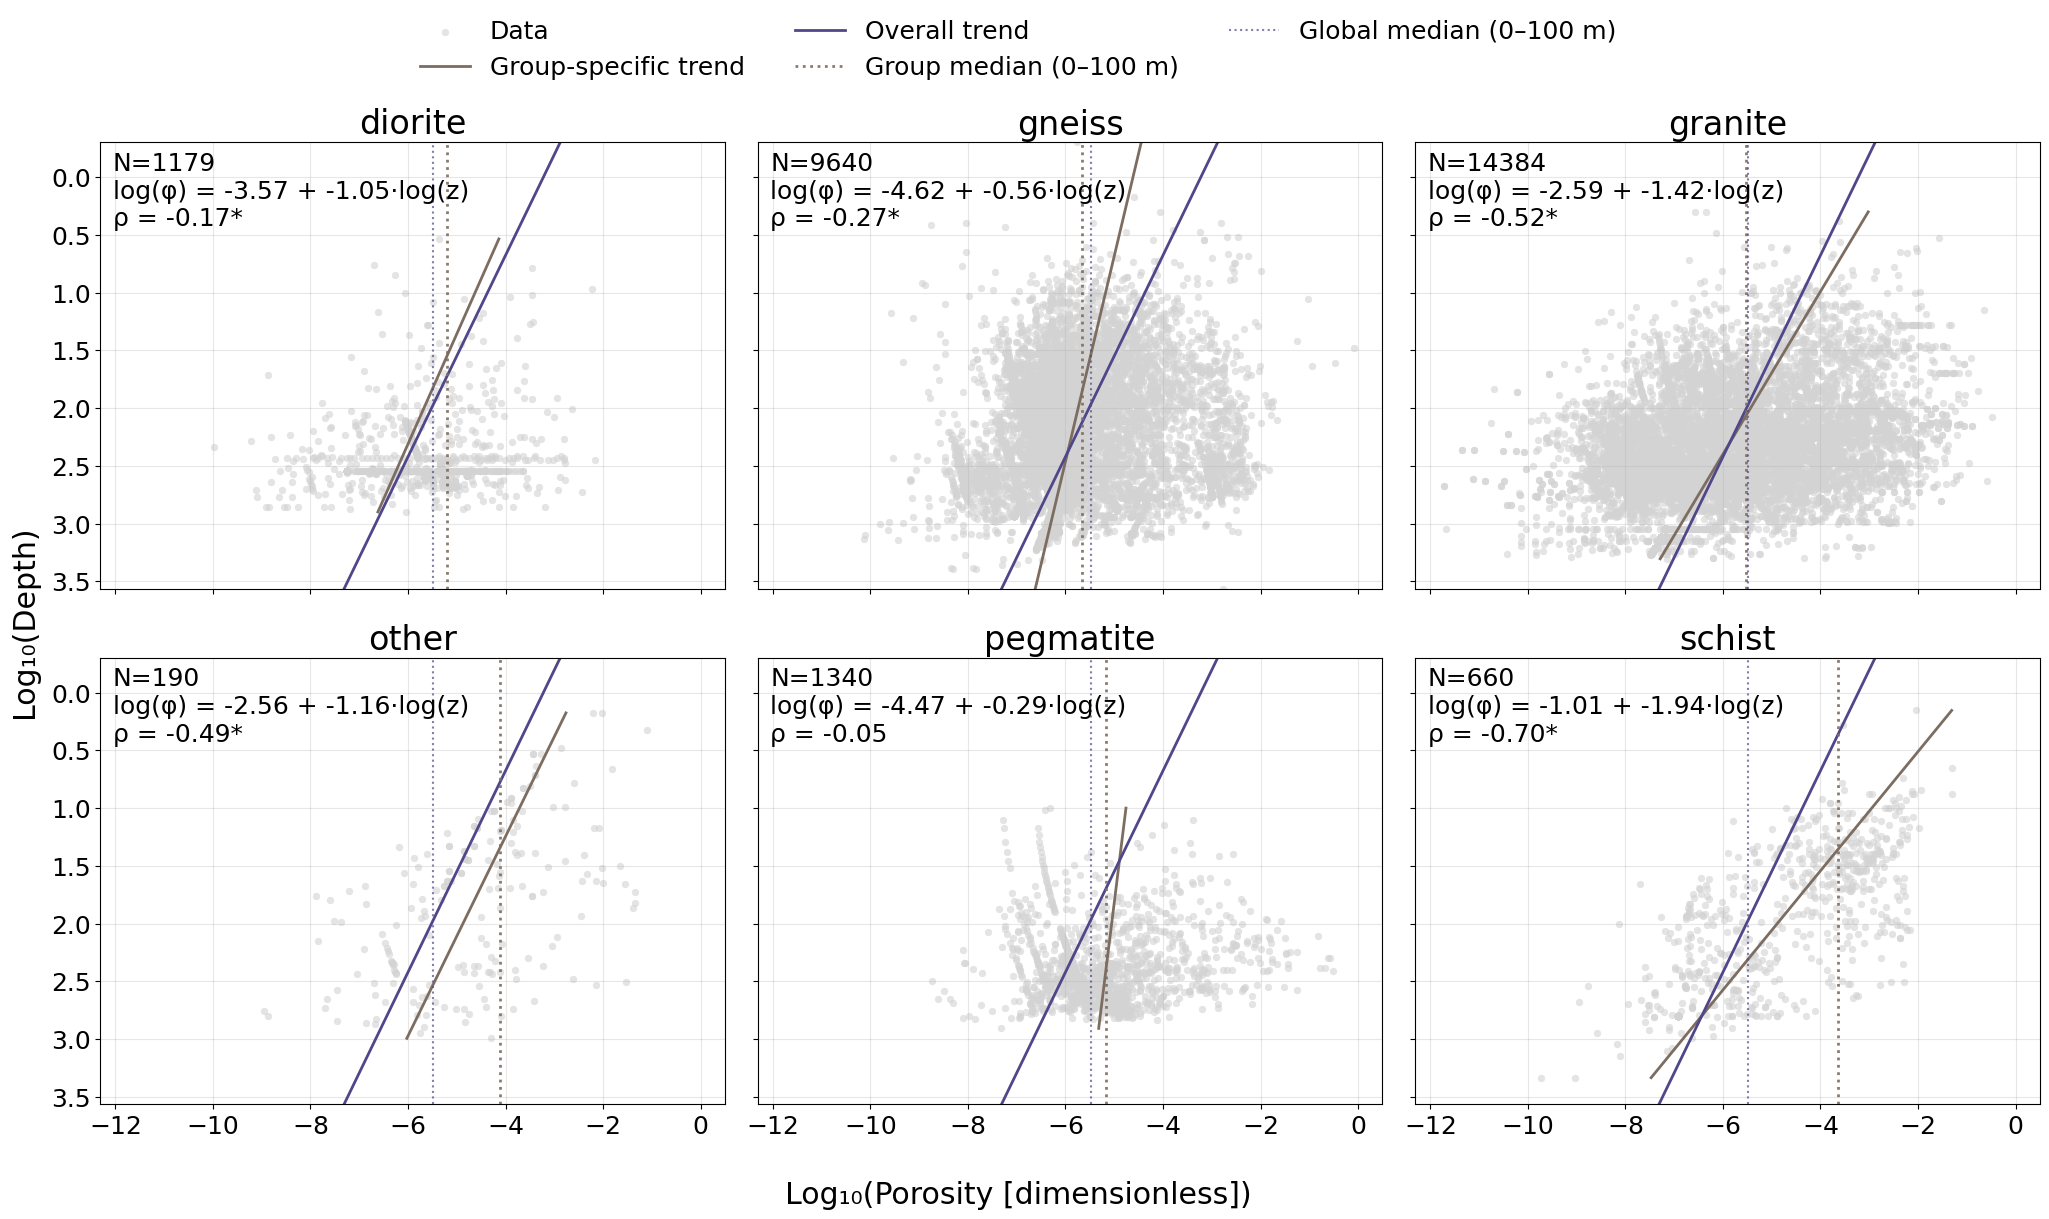

In [99]:
analyze_porosity_depth_by_group(
    df_clean,
    group_col="rock_type",
    output_path="figS03.png"
)



=== Does grouping affect porosity (ignoring depth)? ===
Kruskal–Wallis H = 559.89, p = 9.331e-119
Conclusion: YES — 'plate_boundary_type' influences porosity distributions overall.

=== Which groups contribute to porosity (one-vs-all on porosity) ===
  dextral transform: ↑ porosity vs rest (Holm p=1.777e-49) — Δmedian=7.641e-06 (group 8.213e-06 vs rest 5.716e-07), Cliff’s δ=0.328 (small).
  collision zone: ↓ porosity vs rest (Holm p=4.481e-43) — Δmedian=-1.197e-06 (group 5.444e-07 vs rest 1.742e-06), Cliff’s δ=-0.154 (small).
  extension zone: ↑ porosity vs rest (Holm p=7.522e-39) — Δmedian=3.399e-06 (group 3.972e-06 vs rest 5.728e-07), Cliff’s δ=0.297 (small).
  subduction zone: ↓ porosity vs rest (Holm p=1.468e-19) — Δmedian=-5.563e-07 (group 5.718e-08 vs rest 6.135e-07), Cliff’s δ=-0.201 (small).
  spreading center: ↑ porosity vs rest (Holm p=7.34e-11) — Δmedian=8.043e-06 (group 8.633e-06 vs rest 5.904e-07), Cliff’s δ=0.291 (small).
  sinistral transform: ↑ porosity vs rest (Holm p

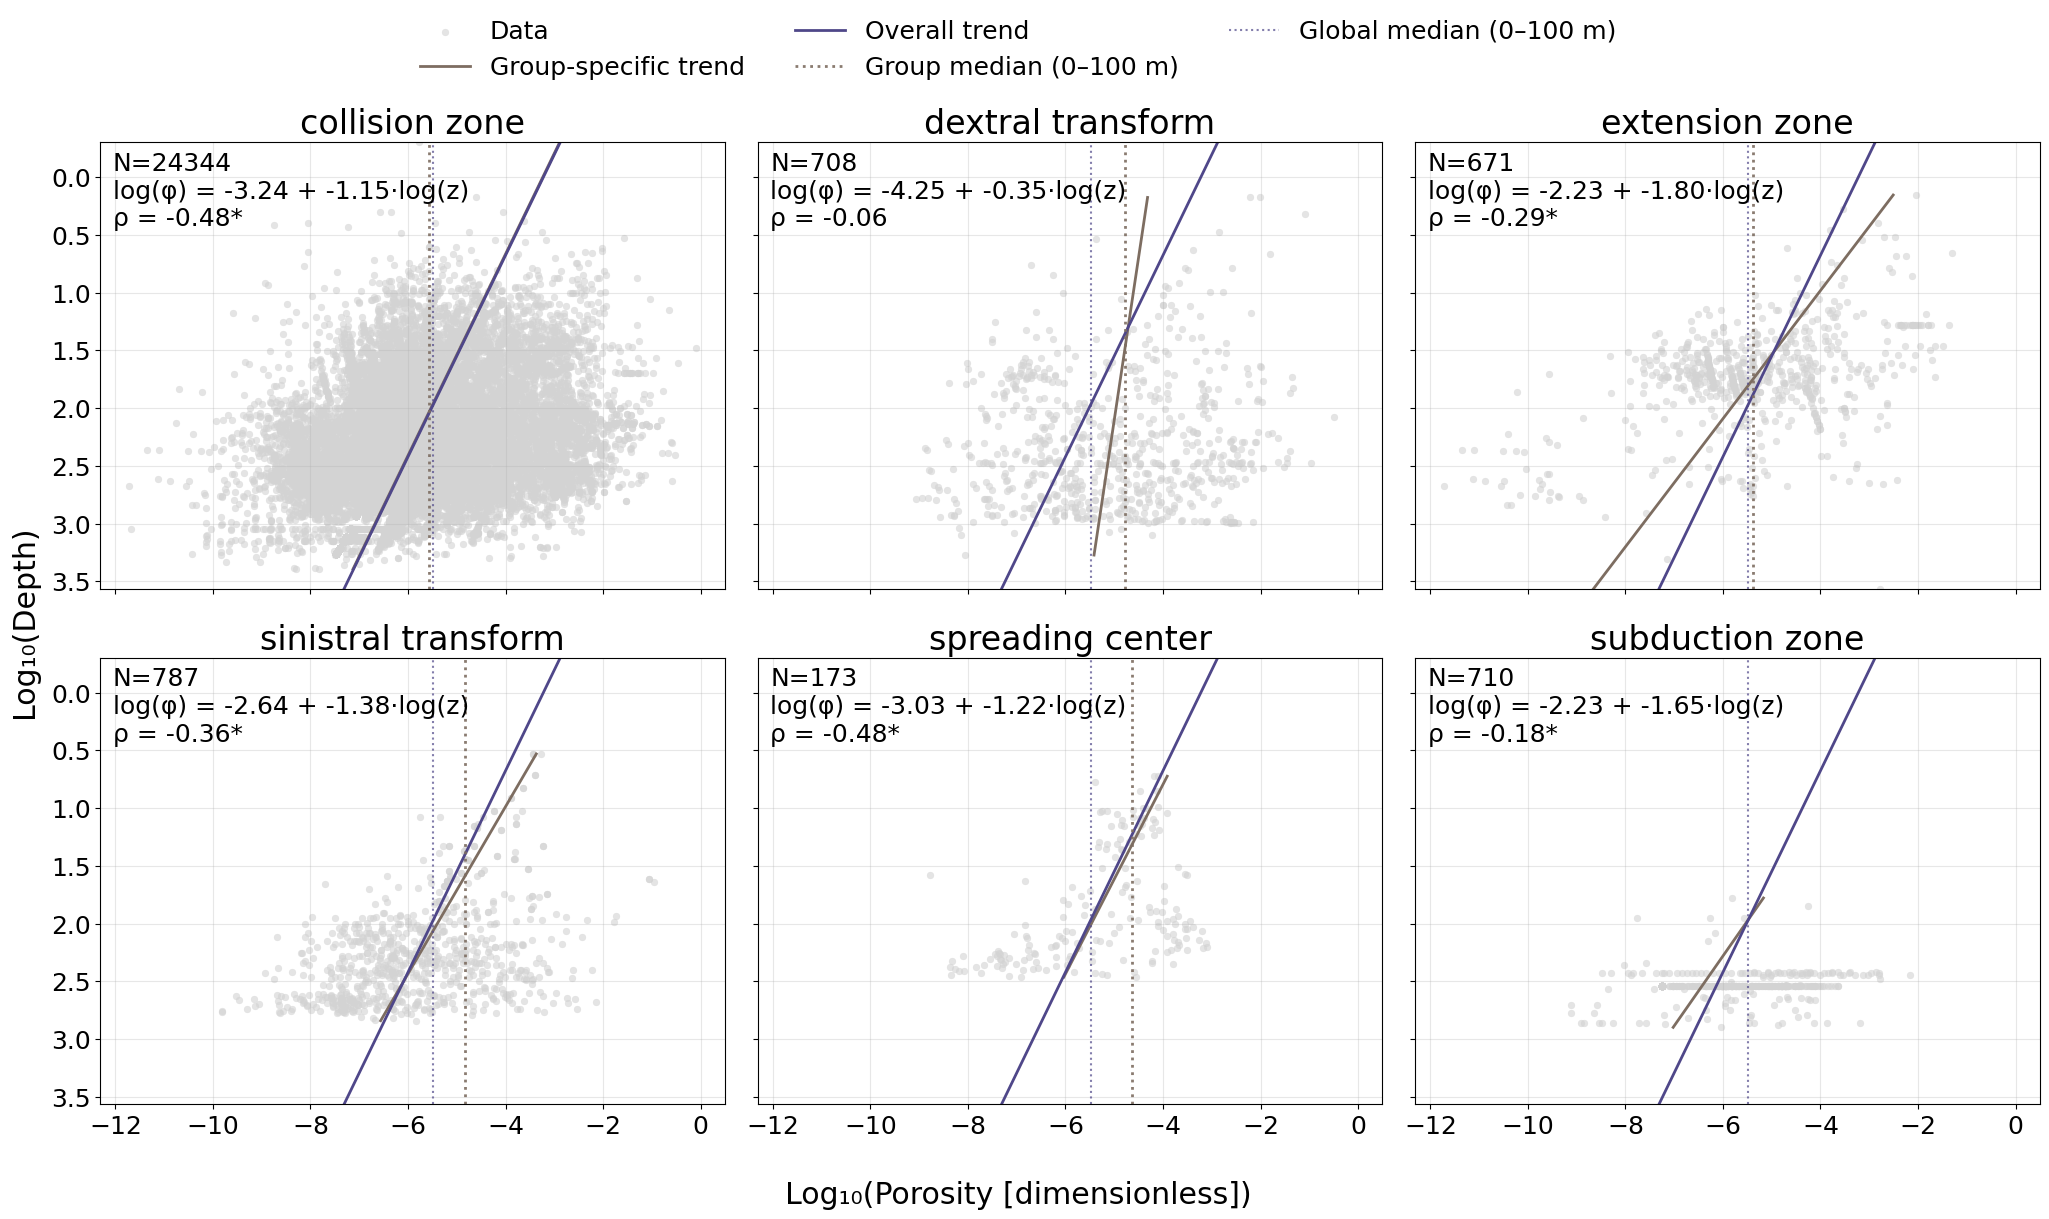

In [100]:
analyze_porosity_depth_by_group(
    df_clean,
    group_col="plate_boundary_type",
    output_path="figS05.png"
)



=== Does grouping affect porosity (ignoring depth)? ===
Kruskal–Wallis H = 3852.00, p = 0
Conclusion: YES — 'tectonic_setting' influences porosity distributions overall.

=== Which groups contribute to porosity (one-vs-all on porosity) ===
  orogenic belt: ↓ porosity vs rest (Holm p=0) — Δmedian=-1.15e-06 (group 1.253e-07 vs rest 1.275e-06), Cliff’s δ=-0.389 (medium).
  shield: ↑ porosity vs rest (Holm p=2.772e-215) — Δmedian=3.046e-06 (group 3.511e-06 vs rest 4.647e-07), Cliff’s δ=0.320 (small).
  craton: ↑ porosity vs rest (Holm p=8.926e-136) — Δmedian=2.025e-05 (group 2.078e-05 vs rest 5.339e-07), Cliff’s δ=0.358 (medium).
  volcanic arc: ↑ porosity vs rest (Holm p=5.065e-82) — Δmedian=5.123e-07 (group 1.017e-06 vs rest 5.051e-07), Cliff’s δ=0.190 (small).
  accretionary complex: ↑ porosity vs rest (Holm p=5.004e-51) — Δmedian=3.412e-07 (group 8.469e-07 vs rest 5.058e-07), Cliff’s δ=0.170 (small).
  magmatic province: ↓ porosity vs rest (Holm p=2.08e-15) — Δmedian=-1.95e-07 (group 

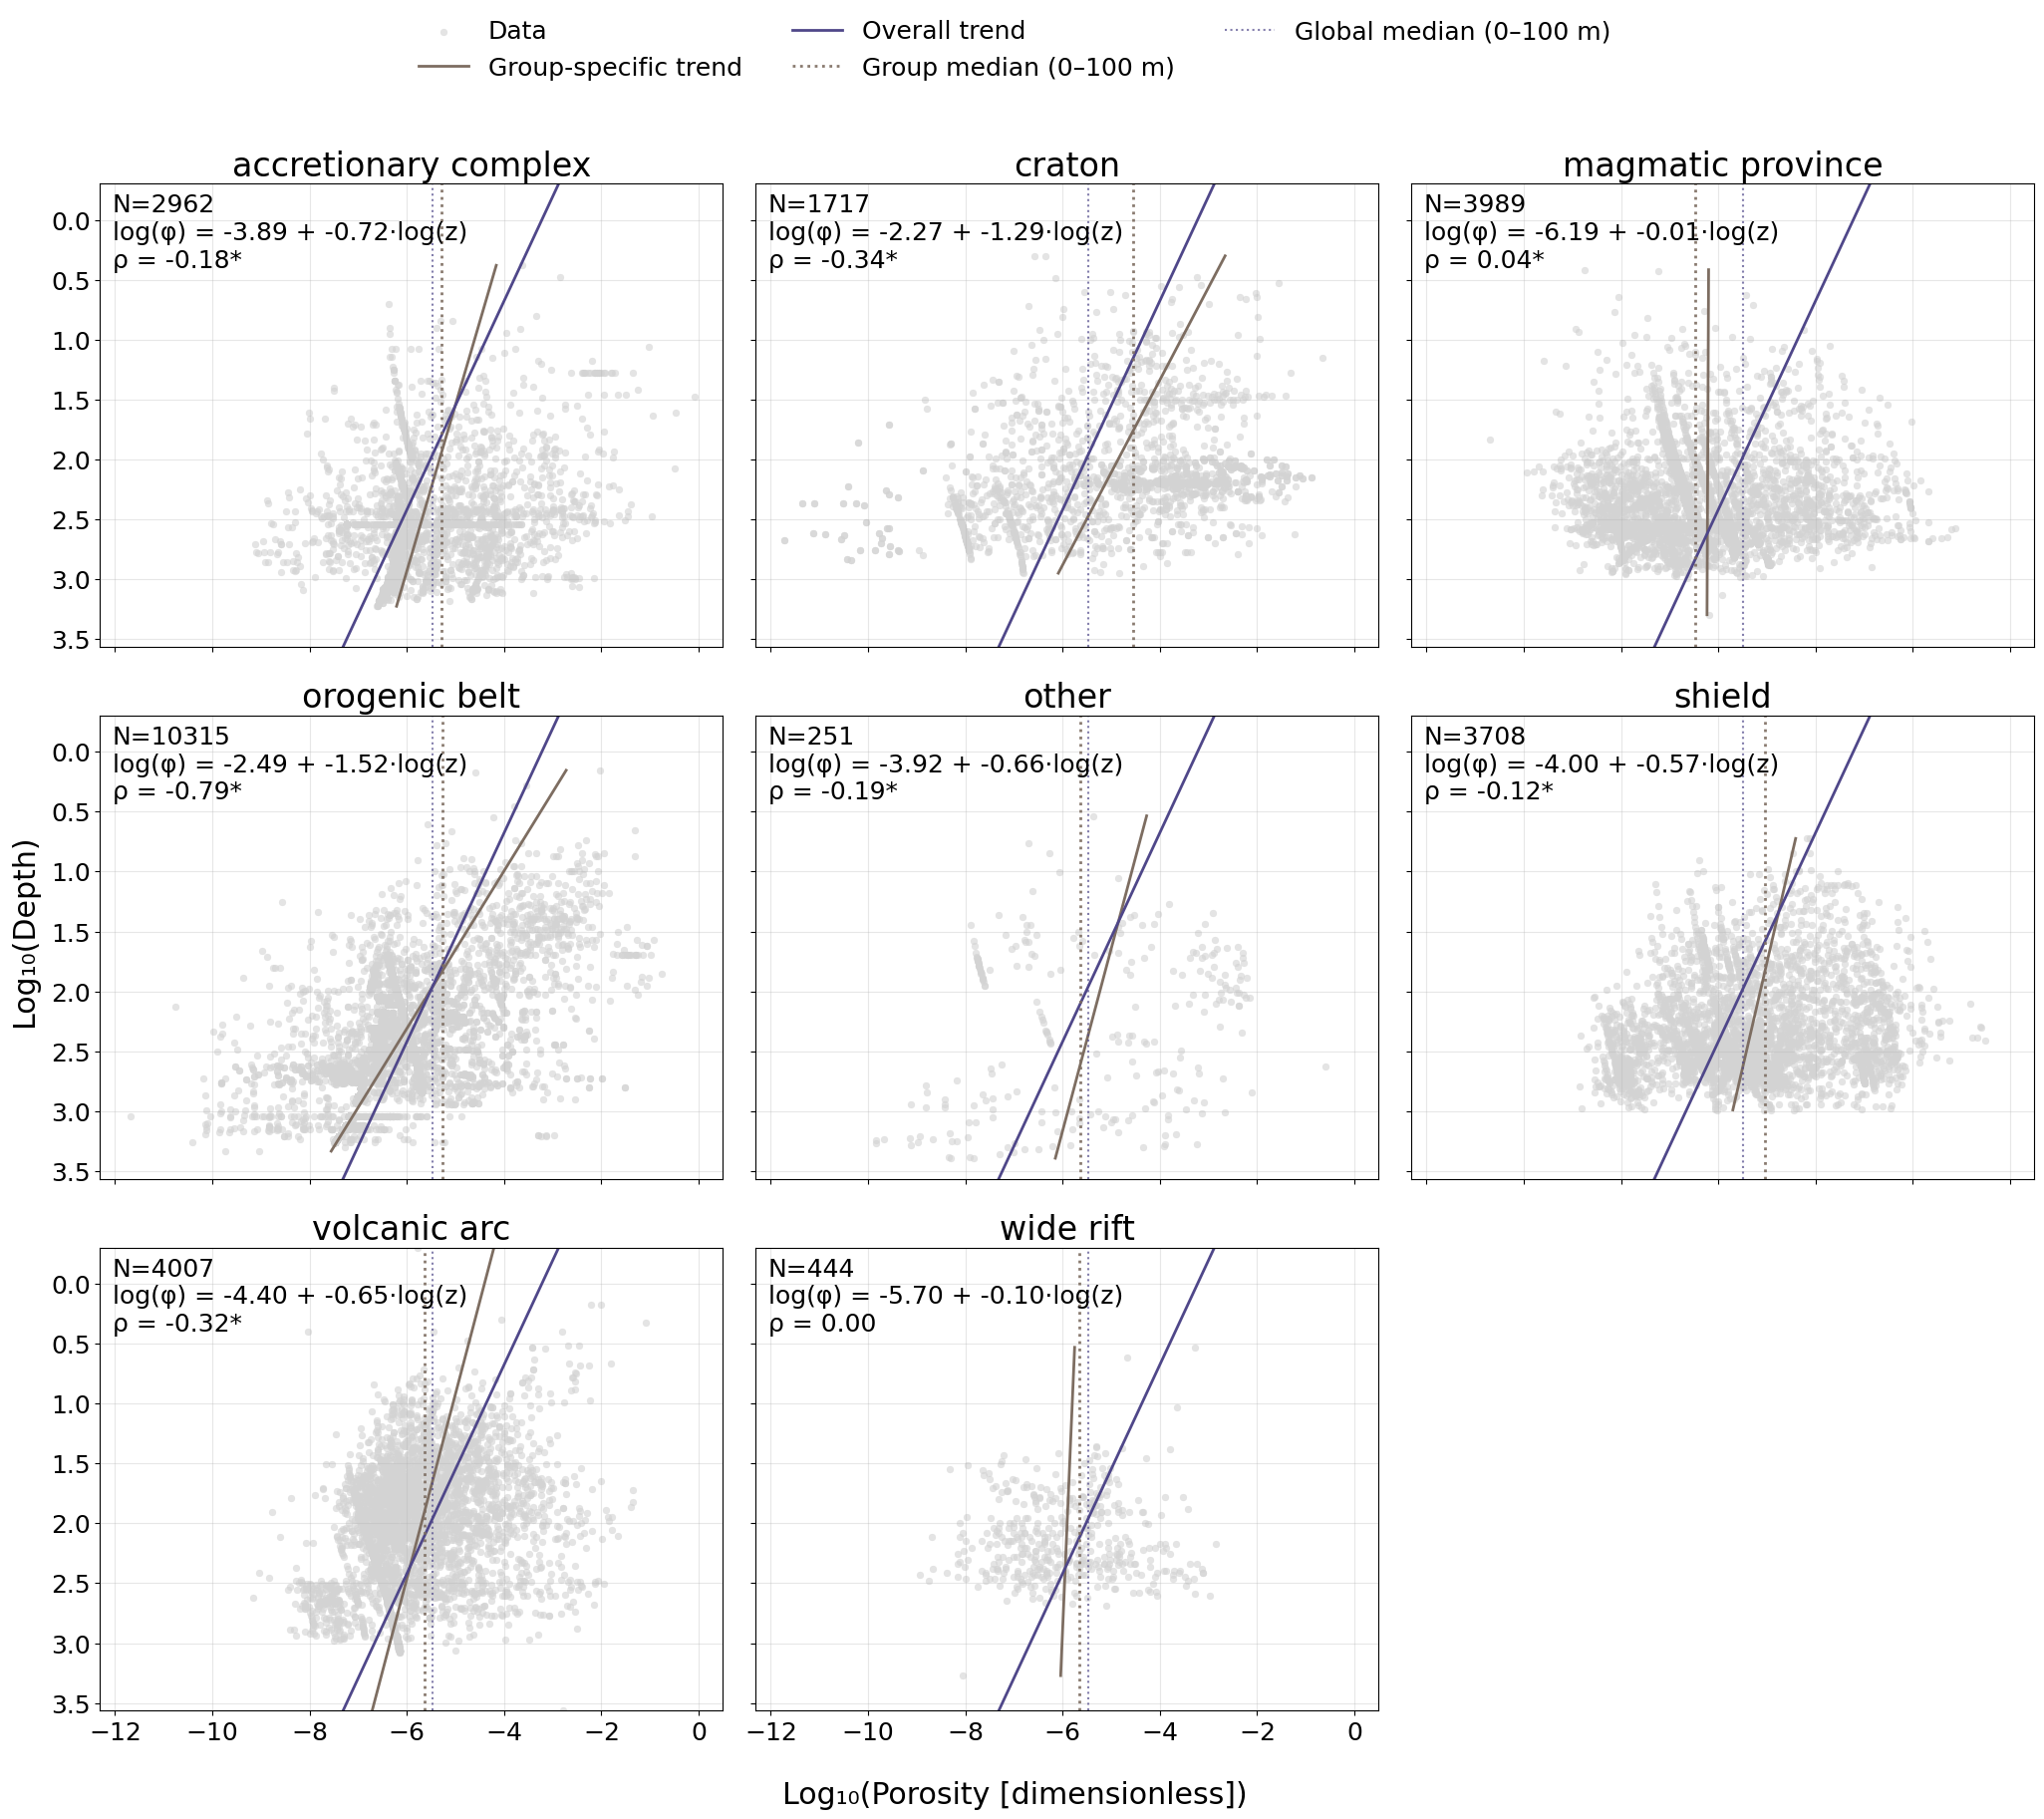

In [101]:
analyze_porosity_depth_by_group(
    df_clean,
    group_col="tectonic_setting",
    output_path="figS04.png"
)


### Fracture density

Porosity = aperture * fracture density --> estimate fracture density

plot depth vs porosity our estimations vs porosity = aperture * facture density, when do they line up?
Which decrease in facture would fit our line? 

Porosity = aperture * fracture density --> fracture density = porosity/aperture

In [102]:
df_begin['fracture_density']=df_begin['porosity']/df_begin['aperture']
df_all['fracture_density']=df_all['porosity']/df_all['aperture']


In [103]:
spearman_depth_porosity(df_begin, depth_col='depth', porosity_col='fracture_density')
spearman_depth_porosity(df_all, depth_col='depth', porosity_col='fracture_density')

✅ Spearman correlation is significant (p = 0.00e+00), correlation coefficient ρ = -0.3450 (negative relationship)
✅ Spearman correlation is significant (p = 0.00e+00), correlation coefficient ρ = -0.3365 (negative relationship)


Linear Fit Formula: log10(fracture_density) = -0.7962 * log10(depth) + 0.1526
fracture_density = 10**(0.1526) * depth**(-0.7962)
R² = 0.0885
Linear Fit Formula: log10(fracture_density) = -0.7653 * log10(depth) + 0.0895
fracture_density = 10**(0.0895) * depth**(-0.7653)
R² = 0.0864


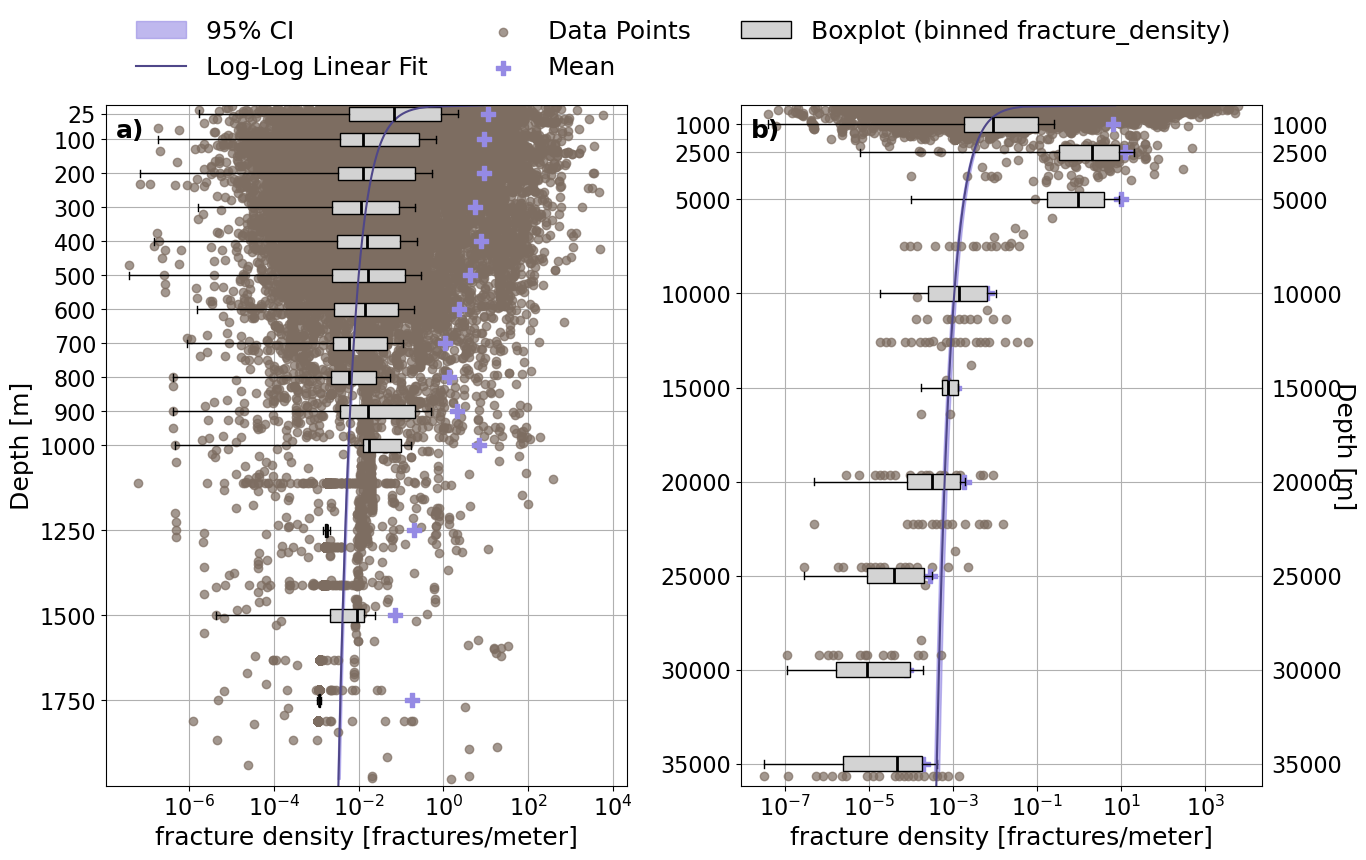

In [104]:
df_begin,mean_density_x,median_density_xn=fracture_density_point(df_begin, distribution_on='no', porosity_relation='no')
df_all,mean_density_x,median_density_xn=fracture_density_point(df_all, distribution_on='no', porosity_relation='no')

results = plot_fracture_vs_depth(
    df_list=[df_begin, df_all],
    bin_edges_list=[
        [0.0, 50, 150, 250, 350, 450, 550, 650, 750, 850, 950, 1050, 1450, 1550, 1950],
        [0.0, 2000, 3000, 7000, 13000.0, 17000, 23000.0, 27000, 33000, 37000]
    ],
    widths_list=[40, 800],
    depth_max_list=[2000, df_all['depth'].max() + 500],
    output_path="fig03.png",
    folder=folder,
    output_data=output_data
)


In [105]:
# from which depth is the line valid
#find where from top to bottom the geometric mean of the data is close to the median of the predicted value at that depth

def valid_point_graph_fracture(df):
    params, r_squared = linear_fit_fracture(df, printing='off')
    a = 0
    valid_depth_found = False

    for i in np.arange(1, 50, 0.01):
        # Select data between a and i (inclusive lower bound, exclusive upper)
        df_select = df[(df['depth'] >= a) & (df['depth'] < i)]

        if len(df_select) == 0:
            continue
        
        # Compute geometric mean of porosity
        log_vals = np.log10(df_select['fracture_density'])
        geom_mean = np.exp(log_vals.mean())

        average_depth = i  # or (i + a) / 2 if you want midpoint

        # Calculate predicted porosity from fitted params
        log_p = params[0] * np.log10(average_depth) + params[1]
        p = np.exp(log_p)  # back-transform log(porosity)

        # Check if predicted value is within 10% of geometric mean
        if (p < geom_mean * 1.1) and (p > geom_mean * 0.9) and not valid_depth_found:
            print(f'Depth low = {average_depth:.2f}')
            valid_depth_found = True

    print('end run')


valid_point_graph_fracture(df_begin)
print("\n")

valid_point_graph_fracture(df_all)


Depth low = 1.43
end run


Depth low = 1.43
end run


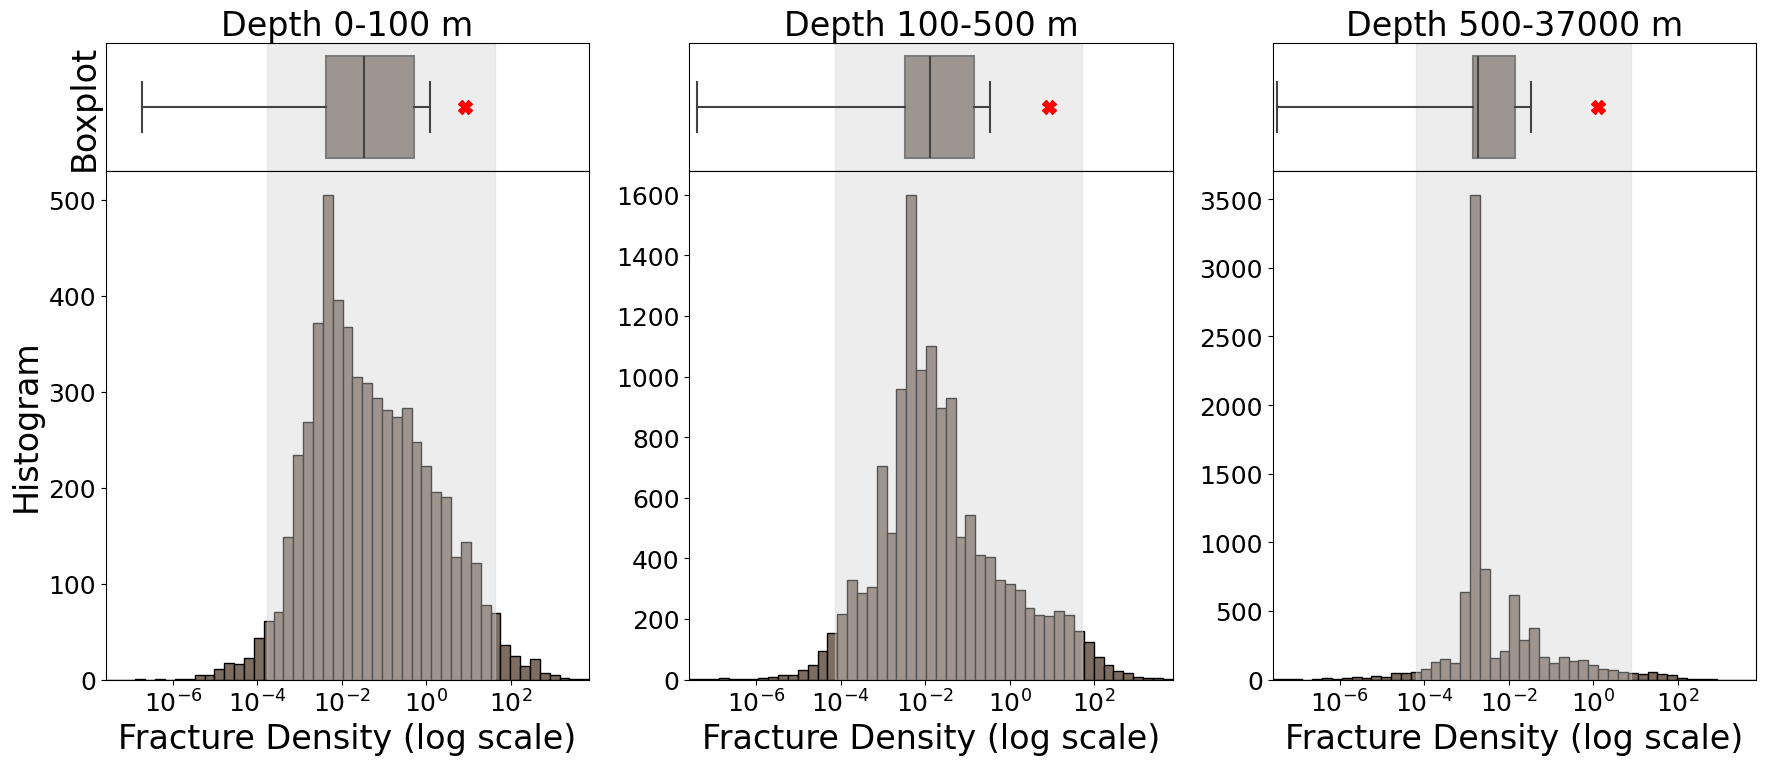

In [106]:


def plot_density_by_depth(df, depth_ranges):
    fig, axs = plt.subplots(
        2, 3, figsize=(18, 8), sharex='col',
        gridspec_kw={'height_ratios': [1, 4], 'hspace': 0}
    )

    all_data = []
    all_stats = []

    # Collect data in each range
    for (low, high) in depth_ranges:
        data = df[(df['depth'] >= low) & (df['depth'] < high)]['fracture_density']
        data = data[data > 0]
        all_data.append(data)

    # Combine all valid data for scaling
    all_concat = pd.concat(all_data)
    x_min = all_concat.min() * 0.8
    x_max = all_concat.max() * 1.2
    common_bin_edges = np.logspace(np.log10(x_min), np.log10(x_max), 50)

    for i, ((low, high), data) in enumerate(zip(depth_ranges, all_data)):
        ax_box = axs[0, i]
        ax_hist = axs[1, i]

        # 95% CI
        lower = np.percentile(data, 2.5)
        upper = np.percentile(data, 97.5)

        # --- Boxplot ---
        sns.boxplot(x=data, ax=ax_box, color='#7D6D61', fliersize=0, orient='h')
        mean = data.mean()
        ax_box.plot(mean, 0, 'rX', markersize=10)
        ax_box.axvspan(lower, upper, color='lightgrey', alpha=0.4)
        ax_box.set_xscale('log')
        ax_box.set_xlim([x_min, x_max])
        ax_box.set_title(f"Depth {low}-{high} m")
        ax_box.set_yticks([])
        ax_box.set_xlabel("")

        # --- Histogram ---
        ax_hist.hist(data, bins=common_bin_edges, color='#7D6D61', edgecolor='black')
        ax_hist.axvspan(lower, upper, color='lightgrey', alpha=0.4)
        ax_hist.set_xscale('log')
        ax_hist.set_xlim([x_min, x_max])
        ax_hist.set_xlabel("Fracture Density (log scale)")

        # --- Gather stats ---
        stats = gather_distribution_stats(data, f"{low}–{high} m")
        all_stats.append(stats)

    axs[0, 0].set_ylabel("Boxplot")
    axs[1, 0].set_ylabel("Histogram")

    plt.tight_layout()
    plt.savefig(f"{folder}{output_data}/figS05.png", dpi=900, bbox_inches='tight',transparent=True)
    plt.show()

    # Convert stats to DataFrame
    stats_df = pd.DataFrame(all_stats)
    return stats_df


# Example usage
depth_ranges = [(0, 100), (100, 500), (500, 37000)]
summary_df = plot_density_by_depth(df_all, depth_ranges)


In [107]:
def check_distribution_fracture(df_all, depth_intervals):
   
    for col_idx, (depth_min, depth_max) in enumerate(depth_intervals):
       
        # --- Row 1: Raw fracture_density (df_all) ---
        filtered_df_all = df_all[(df_all['depth'] >= depth_min) & (df_all['depth'] < depth_max)]
        fracture_density_values = filtered_df_all['fracture_density'].dropna()
        print('estimations')
        test_distributions_print(fracture_density_values, alpha=0.05, test='not simple')
        print('\n')
       

# Call the function
depth_ranges = [(0, 100), (100, 500), (500, 37000)]
check_distribution_fracture(df_all, depth_ranges)


estimations
Right-skewed (positively skewed)
The data does NOT fit the norm distribution (p = 0.000)
The data does NOT fit the expon distribution (p = 0.000)
The data does NOT fit the gamma distribution (p = 0.000)
The data does NOT fit the beta distribution (p = 0.000)
The data does NOT fit the lognorm distribution (p = 0.000)
The data does NOT fit the uniform distribution (p = 0.000)
The data does NOT fit the weibull_min distribution (p = 0.000)
The data does NOT fit the weibull_max distribution (p = 0.000)
The data does NOT fit the pareto distribution (p = 0.000)
The data does NOT fit the triang distribution (p = 0.000)
The data does NOT fit the cauchy distribution (p = 0.000)
The data does NOT fit the laplace distribution (p = 0.000)


estimations
Right-skewed (positively skewed)
The data does NOT fit the norm distribution (p = 0.000)
The data does NOT fit the expon distribution (p = 0.000)
The data does NOT fit the gamma distribution (p = 0.000)
The data does NOT fit the beta dist

In [108]:
def print_summary_ratios(stats_df):
    # Work on a copy of the DataFrame
    raw = stats_df.copy().reset_index(drop=True)
    depth_labels = ["0–100", "100–500", "500–37000"]

    # -----------------------------
    # 1. Median, Mean, Mean/Median for 0–100 m
    # -----------------------------
    try:
        median_0 = raw.loc[0, "median"]
        mean_0 = raw.loc[0, "mean"]
        print("1. Raw fracture density summary (0–100 m):")
        print(f"   Median      = {median_0:.2e}")
        print(f"   Mean        = {mean_0:.2e}")
        print(f"   Mean/Median = {mean_0 / median_0:.2f}")
    except KeyError as e:
        print(f"  ⚠️ Missing column: {e}")
    except IndexError:
        print("  ⚠️ Index 0 out of range. Check your DataFrame.")
    except ZeroDivisionError:
        print("  ⚠️ Division by zero in Mean/Median calculation.")

    # -----------------------------
    # 2. Absolute IQRs for all depths
    # -----------------------------
    print("\n2. Absolute IQR for all depth intervals:")
    for i, depth in enumerate(depth_labels):
        try:
            q1 = raw.loc[i, "Q1"]
            q3 = raw.loc[i, "Q3"]
            iqr = q3 - q1
            print(f"   Depth {depth}: IQR = {iqr:.3f}")
        except KeyError as e:
            print(f"  ⚠️ Missing column: {e}")
        except IndexError:
            print(f"  ⚠️ Index {i} out of range.")

    # -----------------------------
    # 3. Median/Mean ratios for all depths
    # -----------------------------
    print("\n3. Median/Mean ratios for all depth intervals:")
    for i, depth in enumerate(depth_labels):
        try:
            median = raw.loc[i, "median"]
            mean = raw.loc[i, "mean"]
            ratio = median / mean
            print(f"   Depth {depth}: Median/Mean = {ratio:.2e}")
        except KeyError as e:
            print(f"  ⚠️ Missing column: {e}")
        except IndexError:
            print(f"  ⚠️ Index {i} out of range.")
        except ZeroDivisionError:
            print(f"  ⚠️ Division by zero for depth {depth}.")



print_summary_ratios(summary_df)


1. Raw fracture density summary (0–100 m):
   Median      = 3.32e-02
   Mean        = 8.24e+00
   Mean/Median = 247.97

2. Absolute IQR for all depth intervals:
   Depth 0–100: IQR = 0.502
   Depth 100–500: IQR = 0.138
   Depth 500–37000: IQR = 0.013

3. Median/Mean ratios for all depth intervals:
   Depth 0–100: Median/Mean = 4.03e-03
   Depth 100–500: Median/Mean = 1.51e-03
   Depth 500–37000: Median/Mean = 1.41e-03


### Discussion

Lines in CSV: [0.01  0.04  0.065 0.1   0.15  0.2  ]


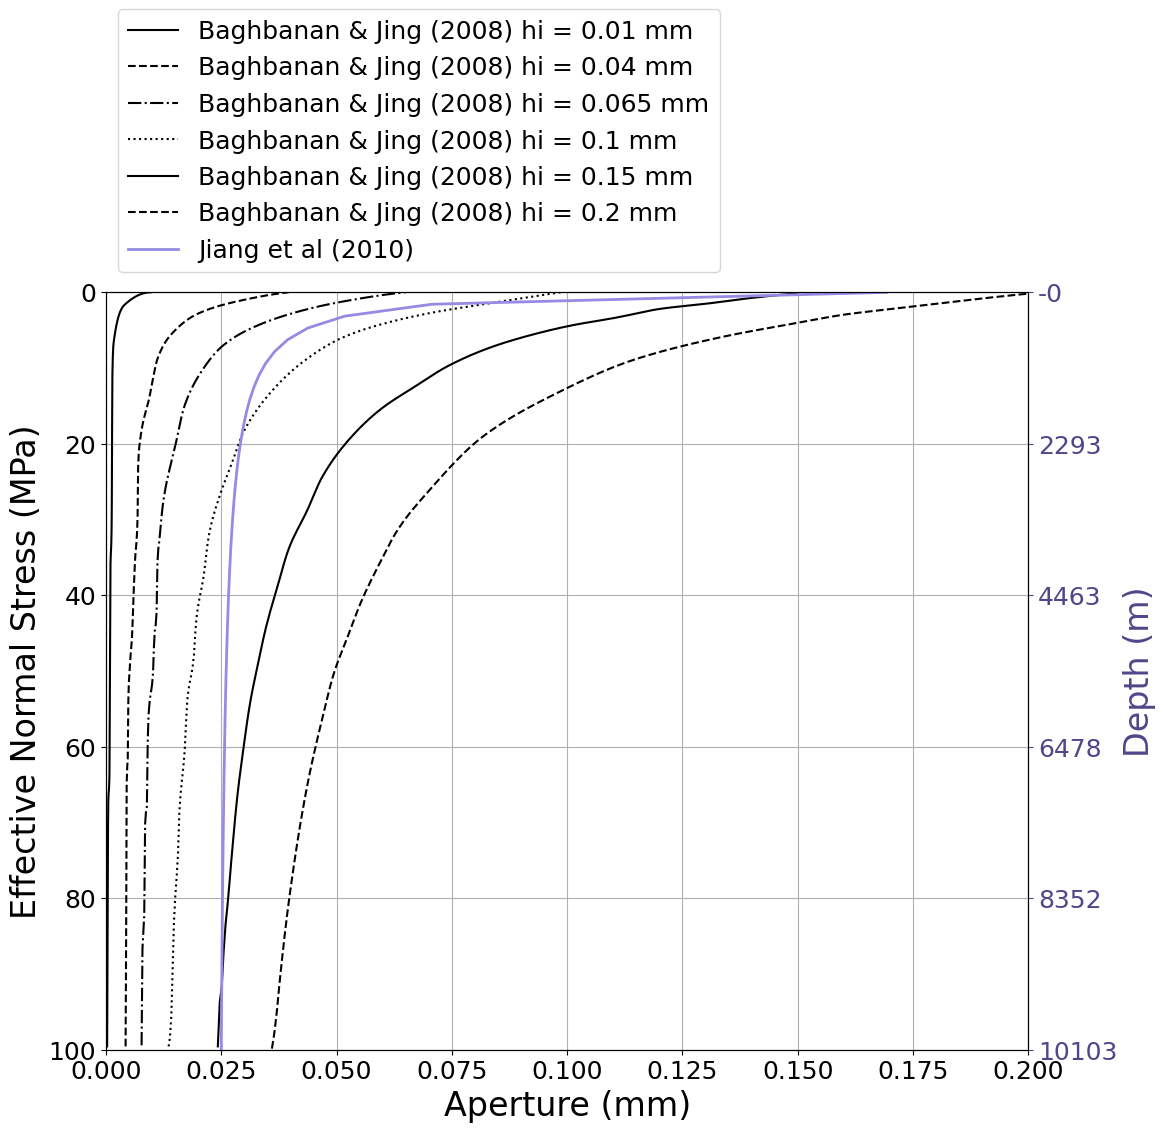

In [109]:
# Constants
R = 83.14467  # cm³·bar/(mol·K)
M_H2O = 18.015  # g/mol (Molar mass of water)
Tc = 647.25  # K (Critical temperature of water)
Vc = 55.9480373  # cm³/mol (Critical volume of water)

# EOS Parameters
params = {
    "a1": 3.49824207e-01, "a2": -2.91046273e+00, "a3": 2.00914688e+00,
    "a4": 1.12819964e-01, "a5": 7.48997714e-01, "a6": -8.73207040e-01,
    "a7": 1.70609505e-02, "a8": -1.46355822e-02, "a9": 5.79768283e-02,
    "a10": -8.41246372e-04, "a11": 4.95186474e-03, "a12": -9.16248538e-03,
    "a13": -1.00358152e-01, "a14": -1.82674744e-03, "gamma": 1.05999998e-02
}

# EOS function to solve for molar volume V
def eos_function(V, T, P):
    Vr = V / Vc  # Reduced volume
    Tr = T / Tc  # Reduced temperature

    # Compute EOS terms
    B = params["a1"] + params["a2"] / Tr**2 + params["a3"] / Tr**3
    C = params["a4"] + params["a5"] / Tr**2 + params["a6"] / Tr**3
    D = params["a7"] + params["a8"] / Tr**2 + params["a9"] / Tr**3
    E = params["a10"] + params["a11"] / Tr**2 + params["a12"] / Tr**3
    F = params["a13"] / Tr
    G = params["a14"] * Tr

    Z = (1 + B/Vr + C/Vr**2 + D/Vr**4 + E/Vr**5 +
         ((F/Vr**2 + G/Vr**4) * np.exp(-params["gamma"] / Vr**2)))
    
    return (Z * R * T / P) - V  # Solve for V

def calculate_Z(V, T, P):
    Vr = V / Vc  # Reduced volume
    Tr = T / Tc  # Reduced temperature

    # Compute EOS terms
    B = params["a1"] + params["a2"] / Tr**2 + params["a3"] / Tr**3
    C = params["a4"] + params["a5"] / Tr**2 + params["a6"] / Tr**3
    D = params["a7"] + params["a8"] / Tr**2 + params["a9"] / Tr**3
    E = params["a10"] + params["a11"] / Tr**2 + params["a12"] / Tr**3
    F = params["a13"] / Tr
    G = params["a14"] * Tr

    Z = (1 + B/Vr + C/Vr**2 + D/Vr**4 + E/Vr**5 +
         ((F/Vr**2 + G/Vr**4) * np.exp(-params["gamma"] / Vr**2)))
    
    return Z

def calculate_fluid_density(z):
    P = 1000 * 9.81 * z / (10**5)  # Pressure in bar
    T = (z / 1000) * 25 + 273.15   # Temperature in K

    # Initial guess for molar volume (Vc is a good starting point)
    V_guess = 18

    # Solve for V using the EOS function
    V_solution = fsolve(eos_function, V_guess, args=(T, P))[0]

    # Calculate Z
    Z = calculate_Z(V_solution, T, P)

    # Calculate density using ρ = M * P / (Z * R * T)
    rho = (M_H2O * P) / (Z * R * T)  # Density in g/cm³

    return rho * 1000  # Convert to kg/m³


# -------------------------------
# Load CSV
# -------------------------------
path_df = os.path.join(folder+input_data, 'Baghbanen_plot.csv')
df1= pd.read_csv(path_df)

# Unique line values
lines = df1["Line"].unique()
print("Lines in CSV:", lines)

# -------------------------------
# Define line styles for Baghbanan & Jing (2008)
# -------------------------------
line_styles = ['-', '--', '-.', ':']  # Extend if needed
style_map = {line: line_styles[i % len(line_styles)] for i, line in enumerate(lines)}

# -------------------------------
# Create main plot
# -------------------------------
fig, ax1 = plt.subplots(figsize=(12, 12))

# Plot Baghbanan & Jing (2008) lines from CSV
for line_value, g in df1.groupby("Line"):
    x = g["x"].values
    y = g["y"].values

    # Sort by x
    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]

    # Smooth interpolation
    interp = PchipInterpolator(x, y)
    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = interp(x_smooth)

    # Plot smooth line in black with different style
    ax1.plot(
        x_smooth, y_smooth,
        linestyle=style_map[line_value],
        color='black',
        linewidth=1.5,
        label=f"Baghbanan & Jing (2008) hi = {line_value} mm"
    )

# -------------------------------
# Compute your simulated aperture/stress
# -------------------------------
depth = np.linspace(1, 36000, 200)

eff_norm_stress = np.array([
    effective_normal_stress(d, bulk_density, angle) for d in depth
])

aperture = np.array([
    aperture_value(d, initial_aperture, reduction_value, init_norm_stiffness, bulk_density, angle)
    for d in depth
])

aperture_mm = aperture * 1e3        # m → mm
stress_MPa = eff_norm_stress / 1e6  # Pa → MPa

# Plot simulated line in solid red
ax1.plot(aperture_mm, stress_MPa, color='#958AE4', linewidth=2, label='Jiang et al (2010)')

# -------------------------------
# Axis labels and limits
# -------------------------------
ax1.set_xlabel("Aperture (mm)")
ax1.set_ylabel("Effective Normal Stress (MPa)", color="black")
ax1.set_xlim(0, 0.2)
ax1.set_ylim(0, 100)  # normal
ax1.invert_yaxis()    # <-- reverse y-axis
ax1.tick_params(axis="y", colors="black")
ax1.grid(True)

# -------------------------------
# Secondary y-axis for depth
# -------------------------------
stress_to_depth = interp1d( stress_MPa, depth, bounds_error=False, fill_value="extrapolate" )
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())  # match reversed y-axis
stress_ticks = ax1.get_yticks()
depth_ticks = stress_to_depth(stress_ticks)
ax2.set_yticks(stress_ticks)
ax2.set_yticklabels([f"{d:.0f}" for d in depth_ticks])
ax2.set_ylabel("Depth (m)", color="#4F4789")
ax2.tick_params(axis="y", colors="#4F4789")


# -------------------------------
# Legend and title
# -------------------------------
ax1.legend(loc='center left', bbox_to_anchor=(0.0, 1.2))
#ax1.set_title("Aperture closure with Baghbanan & Jing (2008) lines and simulated curve")
plt.tight_layout()

output_path = folder + output_data + "/Baghbanan_compare.png"
plt.savefig(f"{folder}{output_data}/figS06.png", dpi=900, bbox_inches='tight',transparent=True)

plt.show()


In [110]:

# Step 1: Split the data
fin_swe = df_all[df_all['country'].isin(['Finland', 'Sweden'])]['porosity'].dropna()
rest = df_all[~df_all['country'].isin(['Finland', 'Sweden'])]['porosity'].dropna()

# Step 2: Mann–Whitney U test (non-parametric, no distribution assumptions)
stat, p = mannwhitneyu(fin_swe, rest, alternative='two-sided')

print(f"Mann–Whitney U statistic: {stat:.3f}")
print(f"P-value: {p:.3e}")

# Step 3 (optional): Compare medians for context
print(f"Median Porosity (Finland + Sweden): {fin_swe.median():.2e}")
print(f"Median Porosity (Rest): {rest.median():.2e}")


Mann–Whitney U statistic: 112711666.000
P-value: 1.566e-132
Median Porosity (Finland + Sweden): 1.09e-06
Median Porosity (Rest): 2.94e-07


In [111]:
# Count data points for each group
n_fin_swe = df_all[df_all['country'].isin(['Finland', 'Sweden'])].shape[0]
n_rest = df_all[~df_all['country'].isin(['Finland', 'Sweden'])].shape[0]

print(f"Data points (Finland + Sweden): {n_fin_swe}")
print(f"Data points (Rest): {n_rest}")



Data points (Finland + Sweden): 12273
Data points (Rest): 15693


In [112]:

# Define groups
finland = df_all[df_all['country'] == 'Finland']['porosity'].dropna()
sweden = df_all[df_all['country'] == 'Sweden']['porosity'].dropna()
rest = df_all[~df_all['country'].isin(['Finland', 'Sweden'])]['porosity'].dropna()

# Finland vs Rest (includes Sweden)
stat_f, p_f = mannwhitneyu(finland, rest, alternative='two-sided')

# Sweden vs Rest (includes Finland)
stat_s, p_s = mannwhitneyu(sweden, rest, alternative='two-sided')

# Finland vs Sweden directly
stat_fs, p_fs = mannwhitneyu(finland, sweden, alternative='two-sided')

print(f"Finland vs Rest: U={stat_f:.2e}, p={p_f:.3e}")
print(f"Sweden vs Rest: U={stat_s:.2e}, p={p_s:.3e}")
print(f"Finland vs Sweden: U={stat_fs:.2e}, p={p_fs:.3e}")

# Median comparison for context
print("\nMedian Porosities:")
print(f"Finland: {finland.median():.3e}")
print(f"Sweden: {sweden.median():.3e}")
print(f"Rest: {rest.median():.3e}")


Finland vs Rest: U=4.70e+07, p=2.791e-175
Sweden vs Rest: U=6.57e+07, p=1.136e-40
Finland vs Sweden: U=1.98e+07, p=2.074e-24

Median Porosities:
Finland: 1.195e-06
Sweden: 1.011e-06
Rest: 2.943e-07


In [113]:
# Combine Finland + Sweden
fin_swe = df_all[df_all['country'].isin(['Finland', 'Sweden'])]['porosity'].dropna()

# All data (including Finland & Sweden)
all_data = df_all['porosity'].dropna()

# Median porosity
median_fin_swe = fin_swe.median()
median_all = all_data.median()

# Fold difference (ratio)
ratio = median_fin_swe / median_all

print(f"Median Porosity (Finland + Sweden): {median_fin_swe:.3e}")
print(f"Median Porosity (All Data): {median_all:.3e}")
print(f"Porosity in Finland + Sweden is {ratio:.2f}× higher than the overall median.")


Median Porosity (Finland + Sweden): 1.086e-06
Median Porosity (All Data): 5.702e-07
Porosity in Finland + Sweden is 1.90× higher than the overall median.


In [114]:
# Combine Finland + Sweden
fin_swe = df_all[df_all['country'].isin(['Finland', 'Sweden'])]['porosity'].dropna()

# All data (including Finland & Sweden)
all_data = df_all['porosity'].dropna()

# Median porosity
mean_fin_swe = fin_swe.mean()
mean_all = all_data.mean()

# Fold difference (ratio)
ratio = mean_fin_swe / mean_all

print(f"Median Porosity (Finland + Sweden): {mean_fin_swe:.3e}")
print(f"Median Porosity (All Data): {mean_all:.3e}")
print(f"Porosity in Finland + Sweden is {ratio:.2f}× higher than the overall mean.")


Median Porosity (Finland + Sweden): 3.568e-04
Median Porosity (All Data): 5.048e-04
Porosity in Finland + Sweden is 0.71× higher than the overall mean.


In [115]:

# Define groups
fin_swe = df_all[df_all['country'].isin(['Finland', 'Sweden'])]['porosity'].dropna()
others = df_all[~df_all['country'].isin(['Finland', 'Sweden'])]['porosity'].dropna()

# One-sided test: H1 = Finland+Sweden is HIGHER
stat, p = mannwhitneyu(fin_swe, others, alternative='greater')

print("Mann–Whitney U test (one-sided):")
print(f"U statistic = {stat:.3f}")
print(f"p-value = {p:.3e}")

if p < 0.05:
    print("→ Finland + Sweden porosity is statistically HIGHER (p < 0.05).")
else:
    print("→ Not significant.")


Mann–Whitney U test (one-sided):
U statistic = 112711666.000
p-value = 7.829e-133
→ Finland + Sweden porosity is statistically HIGHER (p < 0.05).


In [116]:
median_0_100 = df_all.loc[
    (df_all["depth"].between(0, 100)),
    "fracture_density"
].median()

print(median_0_100)
print(0.28/median_0_100)


0.033232367563992046
8.425520675312516


In [117]:
median_usa_0_100 = df_all.loc[
    (df_all["country"] == "USA") &
    (df_all["depth"].between(0, 100)),
    "fracture_density"
].median()

print(median_usa_0_100)
print(0.28/median_usa_0_100)

0.13046077579851573
2.1462389617583866
